In [1]:
!rm metadata_.json
!rm metadata_2.json
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

rm: cannot remove 'metadata_.json': No such file or directory
rm: cannot remove 'metadata_2.json': No such file or directory


In [2]:
!pip install sdv
!pip install sdmetrics
!pip install nbformat



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 5.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.0/207.0 kB 5.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.7 MB/s eta 0:00:0000:01


In [3]:
!pip install smartnoise-synth
!pip install --upgrade --no-cache-dir --force-reinstall --no-deps "git+https://github.com/lucaplian/smartnoise-sdk.git#subdirectory=synth"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.6/39.6 MB 49.9 MB/s eta 0:00:00:00:0100:01
  Cloning https://github.com/lucaplian/smartnoise-sdk.git to /tmp/pip-req-build-zyj6bmaj
  Running command git clone --filter=blob:none --quiet https://github.com/lucaplian/smartnoise-sdk.git /tmp/pip-req-build-zyj6bmaj
  Encountered 3 file(s) that should have been pointers, but weren't:
        datasets/PUMS_large.csv
        datasets/askreddit.csv.zip
        datasets/clean_askreddit.csv
  Resolved https://github.com/lucaplian/smartnoise-sdk.git to commit d5ede79e8fcb902b3efbe024d287f022932c505e


In [4]:
!pip install pandas

In [5]:
import pandas as pd
my_df = pd.read_csv("/kaggle/input/datasets/luca191/adult-data-census/adult-data-census.csv",index_col=0)

In [6]:
df_reset = my_df.reset_index()


In [7]:
import numpy as np
df_reset = df_reset.replace('^ ', '', regex=True)
df_reset = df_reset.replace('?', np.nan)


In [8]:
null_values = df_reset.isnull().sum(axis=1)
for i in range(3):
    null_values = list(filter(lambda x: x > i, null_values))
    


In [9]:
df_reset.columns = list(map(lambda x: x.replace(" ", ""), df_reset.columns))

In [10]:
df_reset.columns = list(map(lambda x: x.replace("-", "_"), df_reset.columns))

In [11]:
df_reset_copy = df_reset.dropna()

In [12]:
columns_values = df_reset_copy.columns

In [13]:
is_col_continuos = []
is_col_categorical = []
is_col_categorical_many_examples = []
is_col_discrete = []
is_col_ordinal = []
import math

for elements_cols in df_reset_copy.columns:
    give_exception = False
    if ".float" in str(type(df_reset_copy.at[0, elements_cols])):
        give_exception = True
        for idx in range(len(df_reset_copy[elements_cols])):
            if 'float' in str(type(df_reset_copy.loc[idx, elements_cols])) and math.isnan(df_reset_copy.loc[idx, elements_cols]):
                continue
            give_exception = df_reset_copy.loc[idx, elements_cols] == float(int(df_reset_copy.loc[idx, elements_cols]))
            if give_exception == False:
                break
        if give_exception and df_reset_copy[elements_cols].nunique() < 20:
            is_col_categorical.append(elements_cols)
        elif give_exception and df_reset_copy[elements_cols].nunique() < 50:
            is_col_categorical_many_examples.append(elements_cols)
        else:
            is_col_continuos.append(elements_cols)
    
    elif df_reset_copy[elements_cols].nunique() < 20:
        is_col_categorical.append(elements_cols)
    elif df_reset_copy[elements_cols].nunique() < 50:
        is_col_categorical_many_examples.append(elements_cols)
    elif ".int" in str(type(df_reset_copy.at[0, elements_cols])):
        is_col_discrete.append(elements_cols)
    else:
        is_col_ordinal.append(elements_cols)


In [14]:
df_reset_copy_ = df_reset.copy()

Here we try to reduce the number of unique values from categorical columns, we will replace rare values with 'Others' to reduce balance the dataset.

In [15]:
from collections import Counter
for col_cat in is_col_categorical_many_examples:
    frequency_el = Counter(df_reset_copy[col_cat])
    d = dict(frequency_el)
    d = dict(sorted(d.items(), key=lambda key_val: key_val[1], reverse=True))
    val_len = len(df_reset_copy[col_cat])
    val = 0
    d_new = {}
    for idx, el in enumerate(d):
        val+= d[el]
        d_new[el] = d[el]
        if val > val_len * 0.98:
            break
    
    for nationality in df_reset_copy_[col_cat].unique():
        if nationality not in d_new.keys():
            df_reset_copy_.loc[df_reset_copy_[col_cat]==nationality, col_cat] = 'Others'
            df_reset_copy_.loc[df_reset_copy_[col_cat]==nationality, col_cat] = 'Others'
    is_col_categorical_many_examples.remove(col_cat)
    is_col_categorical.append(col_cat)


In [16]:
cols_to_ignore = []
for cols in df_reset_copy_.columns:
    columns_filtered = list(filter(lambda x: cols in x and cols!=x, df_reset_copy_.columns)) 
    if columns_filtered == []:
        continue
    for extr_column in columns_filtered: 
        extr_column_2 = extr_column
        extr_column = extr_column.replace(cols, "")
        if "num" in extr_column or "numeric" in extr_column:
            #df_reset_copy_ = df_reset_copy_.drop(cols, axis=1)
            is_col_ordinal.append(extr_column_2)
            is_col_categorical.remove(extr_column_2)
            cols_to_ignore.append(cols)
            is_col_categorical.remove(cols)
            break


In [17]:
is_col_OH =is_col_categorical.copy()
for col_val in is_col_categorical:
    if ".int" in str(type(df_reset_copy_.at[0, col_val])) or ".float" in str(type(df_reset_copy_.at[0, col_val])):
        is_col_OH.remove(col_val)
    

In [18]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df_reset_copy[is_col_OH])
one_hot_df = pd.DataFrame(one_hot_encoded,  columns=encoder.get_feature_names_out(is_col_OH))
df_reset_copy = pd.concat([df_reset_copy.drop(is_col_OH, axis=1), one_hot_df], axis=1)

!NEED TO OPTIMIZE HERE, MAYBE USE MATRIX MULTIPLICATION INSTEAD

In [19]:
# THESE TERMS ARE PROTECTED AND CLASSIFIED AS SENSITIVE UNDER THE US EEOC
list_of_sensitive_words = ['race', 'color', 'religion', 'sex', 'gender', 'age', 'disability', 'country', 'region', 'country_of_origin', 'native_country', 'salary']

In [20]:
import numpy as np 

def generate_embedings_index():
    embeddings_index = {}


    f = open('/kaggle/input/datasets/luca191/input/numberbatch-en.txt')

    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
            
    f.close()
    return embeddings_index

In [21]:
import numpy as np
embeddings_index =  generate_embedings_index()

In [22]:
!pip install faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 39.9 MB/s eta 0:00:00:00:0100:01


In [23]:
import faiss
list_of_sensitive_embeddings = np.array([embeddings_index[word] for word in list_of_sensitive_words], dtype=np.float32, order='C')
faiss.normalize_L2(list_of_sensitive_embeddings)

In [24]:
from scipy.stats import chi2_contingency
correlated_values_2 = {}
correlated_values_3 = {}

highest_corr_values = []
correlated_columns = set()
value_cosine_similarity = {}
for idx_col_cat in range(len(is_col_categorical)):

    for idx_col_cat_2 in range(idx_col_cat+1, len(is_col_categorical)):
        col_cat = is_col_categorical[idx_col_cat]
        
        col_cat_2 = is_col_categorical[idx_col_cat_2]
        
        contingency_table = pd.crosstab(df_reset_copy_[col_cat], df_reset_copy_[col_cat_2])
        chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
        n = contingency_table.sum().sum()
        phi2 = chi2_statistic / n
        r, k = contingency_table.shape
        if n == 1:
            v = 0
        else: 
            phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
            k_corr = k - (k - 1) * (k - 2) / (n - 1)
            r_corr = r - (r - 1) * (r - 2) / (n - 1)
            if k_corr == 1 and r_corr == 1:
                v = 0
            elif k_corr != 1 and r_corr==1:
                v = np.sqrt(phi2corr/(k_corr-1))
            elif r_corr != 1 and k_corr == 1:
                v = np.sqrt(phi2corr/(r_corr-1))
            else:
                v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))
        if col_cat not in value_cosine_similarity.keys():
            if col_cat in embeddings_index.keys():
                embedding_word = np.array([embeddings_index[col_cat]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values = np.max(values)
            value_cosine_similarity[col_cat] = values
        else:
            values = value_cosine_similarity[col_cat]

        if col_cat_2 not in value_cosine_similarity.keys():
            if col_cat_2 in embeddings_index.keys():
                embedding_word_2 = np.array([embeddings_index[col_cat_2]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word_2)
                values_2 = np.einsum('jk,lk->jl', embedding_word_2, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values_2 = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values_2 = np.max(values_2)
            value_cosine_similarity[col_cat_2] = values_2
        else:
            values_2 = value_cosine_similarity[col_cat_2]

        

        if v < 0.5 and (values > 0.5 or values_2 > 0.5):
            continue

        
        if v > 0.35:
            
            if (col_cat, col_cat_2) not in correlated_columns or (col_cat_2, col_cat) not in correlated_columns:
                correlated_columns.add((col_cat, col_cat_2))
            if col_cat in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat]
                list_cat_2 = correlated_values_3[col_cat]
                list_cat.append((float(v), col_cat_2))
                list_cat_2.append(col_cat_2)
                correlated_values_2[col_cat] = list_cat
                correlated_values_3[col_cat] = list_cat_2

            else:
                correlated_values_2[col_cat] = [(float(v), col_cat_2)]
                correlated_values_3[col_cat] = [col_cat_2]
            
            if col_cat_2 in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat_2]
                list_cat_2 = correlated_values_3[col_cat_2]
                list_cat.append((float(v), col_cat))
                list_cat_2.append(col_cat)
                correlated_values_2[col_cat_2] = list_cat
                correlated_values_3[col_cat_2] = list_cat_2
            else:
                correlated_values_2[col_cat_2] = [(float(v), col_cat)]
                correlated_values_3[col_cat_2] = [col_cat]
      

In [25]:
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

cramer_values = {}
from scipy.stats import pearsonr
value_with_target = {}
is_col_numeric = is_col_discrete.copy()
is_col_numeric.extend(is_col_continuos)
for col_num_idx in range(len(is_col_numeric)-1):
    for col_num2_idx in range(col_num_idx+1, len(is_col_numeric)):
        col_num = is_col_numeric[col_num_idx]
        col_num2 = is_col_numeric[col_num2_idx]
        corr, _ = pearsonr(df_reset_copy_[col_num], df_reset_copy_[col_num2])
        if abs(corr) > 0.5:
            if col_num in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_num]
                list_cat_2.append(col_num2)
                correlated_values_3[col_num] = list_cat_2

            else:
                correlated_values_3[col_num] = [col_num2]
            
            if col_num2 in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_num2]
                list_cat_2.append(col_num)
                correlated_values_3[col_num2] = list_cat_2
            else:
                correlated_values_3[col_num2] = [col_num]
            



THERE WERE PROBLEMATIC ASSOCIATION BETWEEN SEX AND OCCUPATION, LATER FOR EXAMPLE, WE FOUND That in this dataset, there are no woman in the armed forces, but it is not an impossible situation like the "Unmarried" and "Husband" association, so we try to exclude moderate correlations associations related to sex or gender, in order to avoid bias in the dataset.

In [26]:
for key_ in correlated_values_2.keys():
    list_cat = correlated_values_2[key_]
    list_cat.sort(key=lambda x: x[0], reverse=True)
    correlated_values_2[key_] = list_cat

In [27]:
!pip install statsmodels

In [28]:
!pip install statsmodels

In [29]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
for col_cat in is_col_categorical:
    is_col_numeric = is_col_discrete

    for col_num in is_col_numeric:
        
        model = ols(f'{col_num} ~ {col_cat}',data = df_reset_copy_).fit()
                
        anova_result = sm.stats.anova_lm(model, typ=2)
        eta_2 = anova_result['sum_sq'][col_cat]/(anova_result['sum_sq'][col_cat] + anova_result['sum_sq']['Residual'])

        if col_cat not in value_cosine_similarity.keys():
            if col_cat in embeddings_index.keys():
                embedding_word = np.array([embeddings_index[col_cat]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values = np.max(values)
            value_cosine_similarity[col_cat] = values
        else:
            values = value_cosine_similarity[col_cat]

        if col_cat_2 not in value_cosine_similarity.keys():
            if col_cat_2 in embeddings_index.keys():
                embedding_word_2 = np.array([embeddings_index[col_cat_2]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word_2)
                values_2 = np.einsum('jk,lk->jl', embedding_word_2, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values_2 = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values_2 = np.max(values_2)
            value_cosine_similarity[col_cat_2] = values_2
        else:
            values_2 = value_cosine_similarity[col_cat_2]


    
        if (values > 0.5 or values_2 > 0.5) and eta_2 < 0.35:
            continue

        if eta_2 > 0.16:

            if col_cat in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_cat]
                list_cat_2.append(col_num)
                correlated_values_3[col_cat] = list_cat_2

            else:
                correlated_values_3[col_cat] = [col_num]
            
            if col_num in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_num]
                list_cat_2.append(col_cat)
                correlated_values_3[col_num] = list_cat_2
            else:
                correlated_values_3[col_num] = [col_cat]


The high correlations are related to columns which do not have missing values

There are low correlations between the columns in the dataset, which suggests that the each feature is not correlated with the other, so the inputting must be done in a generalised manner, or through intuition. So there is no need for eliminating columns.

In [30]:
are_missing_values = []
for idx, values in enumerate(df_reset.isnull().sum()):
    if values > 0:
        are_missing_values.append(df_reset.columns[idx])

In [31]:
null_values = df_reset_copy_.isnull().sum(axis=1)
null_values = list(map(lambda x: x[0], list(filter(lambda x: x[1] > i, zip(list(null_values.index), null_values)))))

df_reset_copy_ = df_reset_copy_.drop(null_values)

In [32]:
import warnings
warnings.filterwarnings(
    action='ignore', category=UserWarning, message=r"Boolean Series.*"
)


In [33]:
RuntimeWarning

RuntimeWarning

In [34]:
correlated_dict_ = set()
current_lists = []
correlated_elements_dict = {}
missing_pair_valid = set()
for val_key in correlated_values_3.keys():
    new_list = []
    new_list.append(val_key)
    for values in correlated_values_3[val_key]:
        ok = 0
        if (val_key, values) in correlated_dict_ or (values, val_key) in correlated_dict_:
            continue
        a = len(df_reset_copy_[val_key].unique())
        b = len(df_reset_copy_[values].unique())
        use_a = False
        use_b = False
        if a > b:
            use_a = a > b
        
        for dx in df_reset_copy_[val_key].unique():
            ok = 0
            for dy in df_reset_copy_[values].unique():
                
                if len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy]) < 0.01 * len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx if a > b else df_reset_copy_[values]==dy]):
                    ok = 1
                    idx = df_reset_copy_[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy].index
                    if len(list(idx)) > 0 and ((val_key, values) not in missing_pair_valid and (values, val_key) not in missing_pair_valid):
                        missing_pair_valid.add((val_key, values))

                    if a > b:
                        if len(list(idx)) > 0:
                            df_reset_copy_.loc[list(idx), val_key] = [np.nan] * len(list(idx))
                        if val_key not in are_missing_values:
                            are_missing_values.append(val_key)
                        
                    else:
                        if len(list(idx)) > 0:
                            df_reset_copy_.loc[list(idx), values] = [np.nan] * len(list(idx))
                        if values not in are_missing_values:
                            are_missing_values.append(values)
    
                if ok == 1:
                    break
            if ok == 1:
                break
        if ok == 1:
            new_list.append(values)
            correlated_dict_.add((val_key, values))
    current_lists.append(new_list)
        


In [35]:
for val_key, values in list(missing_pair_valid):
    for dx in df_reset_copy_[val_key].unique():
        for dy in df_reset_copy_[values].unique():
            if len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy]) < 0.01 * len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx if a > b else df_reset_copy_[values]==dy]):
                idx = df_reset_copy_[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy].index
                if a > b:
                    if len(list(idx)) > 0:
                        df_reset_copy_.loc[list(idx), val_key] = [np.nan] * len(list(idx))
                    
                else:
                    if len(list(idx)) > 0:
                        df_reset_copy_.loc[list(idx), values] = [np.nan] * len(list(idx))

 


In [36]:
df_reset_copy_['relationship'][7109]

nan

In [37]:
import math
from numpy.random import choice

from collections import Counter
associate_combined_values_with_input_values = {}
set_combined_values_with_input_values = set()
for col_ in are_missing_values:
    list_val = []
    for idx in df_reset_copy_.index[df_reset_copy_[col_].isnull()]:
        if "str" in str(type(df_reset_copy_[col_][idx])):
            continue
        if math.isnan(df_reset_copy_[col_][idx]):
            combination_ = ""
            relevant_columns = ""
            if col_ in correlated_values_2.keys():
                for col_2 in correlated_values_2[col_]:
                    if ("str" in str(type(df_reset_copy_[col_2[1]][idx])) or math.isnan(df_reset_copy_[col_2[1]][idx])==False):
                        if combination_ != "":
                            combination_+=";"+str(df_reset_copy_[col_2[1]][idx])
                            relevant_columns+=";"+col_2[1]
                        else:
                            combination_=col_+";"+str(df_reset_copy_[col_2[1]][idx])
                            relevant_columns=col_2[1]

                if combination_ not in associate_combined_values_with_input_values.keys():
                    df_new = df_reset_copy_.copy()
                    for cols_split in relevant_columns.split(";"):
                        df_new_2 = df_new[df_new[cols_split]==df_new[cols_split][idx]].copy()
                        if len(df_new_2[col_].copy().dropna())!=0:
                            df_new = df_new_2
            else:
                combination_ = col_+";"
                df_new = df_reset_copy_.copy()

            if combination_ not in associate_combined_values_with_input_values.keys():
                data_last = Counter(df_new[col_].copy().dropna())

                our_value = data_last.most_common(1)[0][0]
                associate_combined_values_with_input_values[combination_] = our_value
            else:
                our_value = associate_combined_values_with_input_values[combination_]
            list_val.append(our_value)

    df_reset_copy_.loc[list(df_reset_copy_.index[df_reset_copy_[col_].isnull()]), col_] = list_val
                
        


In [38]:
for curr_list_idx in range(len(current_lists)-1):
    for curr_list_idx_2 in range(curr_list_idx+1, len(current_lists)):
        common_lists_1 = current_lists[curr_list_idx]
        common_lists_2 = current_lists[curr_list_idx_2]

        common_lists_1.extend(common_lists_2)
        if len(set(common_lists_1)) != len(common_lists_1):
            current_lists[curr_list_idx] = list(set(common_lists_1))
            current_lists[curr_list_idx_2] = []


In [39]:
current_lists = list(filter(lambda x: len(x) > 1, current_lists))

In [40]:
for cols in cols_to_ignore:
    df_reset_copy_ = df_reset_copy_.drop(cols, axis=1)

In [41]:
df_reset_copy_['capital_net'] = df_reset_copy_['capital_gain']-df_reset_copy_['capital_loss']
df_reset_copy_ = df_reset_copy_.drop('capital_gain', axis=1)
df_reset_copy_ = df_reset_copy_.drop('capital_loss', axis=1)

In [42]:
import math
df_reset_copy_['capital_net_log'] = np.sign(df_reset_copy_['capital_net']) * np.log2(abs(df_reset_copy_['capital_net'])+1) 

In [43]:
df_reset_copy_2 = df_reset_copy_.copy()
df_reset_copy_2 = df_reset_copy_2.drop(['capital_net', 'fnlwgt'], axis=1)

In [44]:
df_reset_copy_3 = df_reset_copy_.copy()

for idx, merged_lists in enumerate(current_lists):
    df_reset_copy_2[f"merged_list_{idx}"] = df_reset_copy_2[merged_lists].agg(';'.join, axis=1)

flat_list = [
    x
    for xs in current_lists
    for x in xs
]
df_reset_copy_2=df_reset_copy_2.drop(flat_list, axis=1)

In [45]:
!rm adult-data-census-complete2.csv

rm: cannot remove 'adult-data-census-complete2.csv': No such file or directory


In [46]:
df_reset_copy_2.to_csv("adult-data-census-complete2.csv", index=False)

In [47]:
from sdv.io.local import CSVHandler

connector = CSVHandler()

In [48]:
import pandas as pd
import math
from snsynth import Synthesizer

pums = pd.read_csv("adult-data-census-complete2.csv")

synth = Synthesizer.create("dpctgan", epsilon=3000000, epochs=1800, batch_size=2000, verbose=True)
synth.fit(pums, preprocessor_eps=900000)


/usr/local/lib/python3.12/dist-packages/snsql/sql/odometer.py:79: RuntimeWarning: overflow encountered in exp
  optimal_left_side = np.sum([((np.exp(eps) - 1) * eps) / ((np.exp(eps) + 1)) for eps, _ in self.steps])
/usr/local/lib/python3.12/dist-packages/snsql/sql/odometer.py:79: RuntimeWarning: invalid value encountered in scalar divide
  optimal_left_side = np.sum([((np.exp(eps) - 1) * eps) / ((np.exp(eps) + 1)) for eps, _ in self.steps])


Spent 900000.0 epsilon on preprocessor, leaving 2100000.0 for training


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:638: UserWarning: The sample rate will be defined from ``batch_size`` and ``sample_size``.The returned privacy budget will be incorrect.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:229: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_rng`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Epoch 1, Loss G: 0.7144, Loss D: 1.3783
epsilon is 0.1685669340063301, alpha is 63.0
Epoch 2, Loss G: 0.7051, Loss D: 1.3753
epsilon is 0.35087099872193805, alpha is 59.0
Epoch 3, Loss G: 0.6924, Loss D: 1.3798
epsilon is 0.4932741420837069, alpha is 45.0
Epoch 4, Loss G: 0.6839, Loss D: 1.3882
epsilon is 0.6042796523846699, alpha is 38.0
Epoch 5, Loss G: 0.6777, Loss D: 1.3926
epsilon is 0.6988118744717009, alpha is 33.0
Epoch 6, Loss G: 0.6787, Loss D: 1.3963
epsilon is 0.7828014761953501, alpha is 30.0
Epoch 7, Loss G: 0.6827, Loss D: 1.3951
epsilon is 0.8592371022659602, alpha is 28.0
Epoch 8, Loss G: 0.6920, Loss D: 1.3889
epsilon is 0.9299480108802527, alpha is 26.0
Epoch 9, Loss G: 0.6995, Loss D: 1.3855
epsilon is 0.9962382906342205, alpha is 25.0
Epoch 10, Loss G: 0.7001, Loss D: 1.3866
epsilon is 1.0586989652469627, alpha is 23.0
Epoch 11, Loss G: 0.6964, Loss D: 1.3913
epsilon is 1.1179585973940969, alpha is 22.0
Epoch 12, Loss G: 0.6961, Loss D: 1.3917
epsilon is 1.17469913

In [49]:
synthetic_data_ = synth.sample(len(df_reset_copy_2))

In [50]:
synthetic_data_2 = synthetic_data_.copy()

In [51]:
synthetic_data_['capital_net_log'] = synthetic_data_['capital_net_log'].clip(upper=max(df_reset_copy_2['capital_net_log']), lower=min(df_reset_copy_2['capital_net_log']))

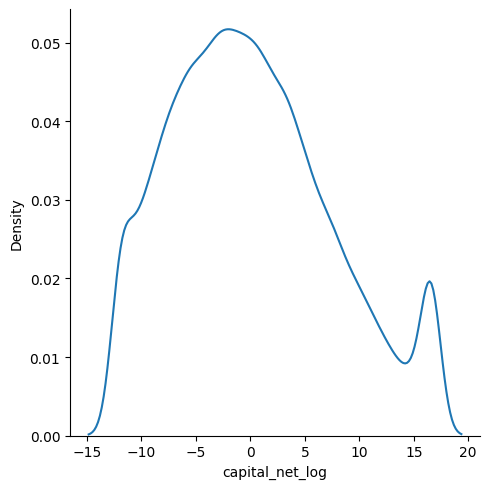

In [52]:
import seaborn as sns

sns.displot(synthetic_data_, x="capital_net_log", kind="kde")

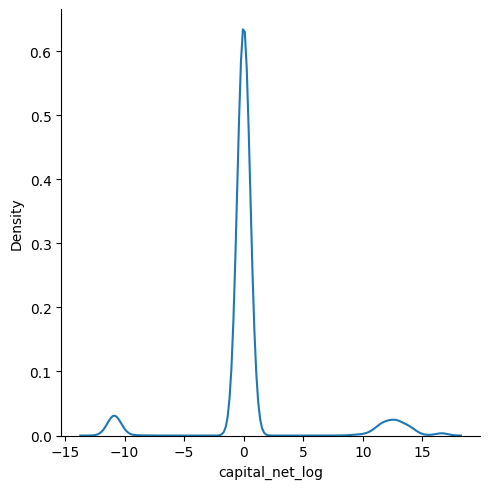

In [53]:
import seaborn as sns

sns.displot(df_reset_copy_2, x="capital_net_log", kind="kde")

In [54]:
max(df_reset_copy_2['capital_net_log'])

16.609640474436812

In [55]:
synthetic_data_3 = synthetic_data_.copy()


In [56]:
df_reset_copy_2 = df_reset_copy.copy()
for idx, merged_lists in enumerate(current_lists):
    cols = synthetic_data_[f"merged_list_{idx}"].str.split(';', expand=True)
    synthetic_data_[merged_lists] = cols
    synthetic_data_ = synthetic_data_.drop(f"merged_list_{idx}", axis=1)


In [57]:
!rm /kaggle/working/adult-data-census-complete2.csv

In [58]:
df_reset_copy_4 = df_reset_copy_.copy()
df_reset_copy_4 = df_reset_copy_4.drop(['fnlwgt', 'capital_net'], axis=1)

In [59]:
df_reset_copy_4.to_csv("adult-data-census-complete2.csv", index=False)

In [60]:
data = connector.read(
    folder_name='',
    file_names=['adult-data-census-complete2.csv'],
    read_csv_parameters={
        'parse_dates': False,
        'encoding':'latin-1'
    }
)

In [61]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(data)

metadata.visualize()
metadata.update_column(
    column_name='education_num',
    sdtype='numerical',
    table_name='adult-data-census-complete2'
)

metadata.validate()


In [62]:
metadata_dict = metadata.to_dict()
metadata_dict['columns'] = metadata_dict['tables']['adult-data-census-complete2']['columns']

In [63]:
from sdmetrics.reports.single_table import QualityReport

report = QualityReport()

report.generate(df_reset_copy_4, synthetic_data_, metadata_dict)

/usr/local/lib/python3.12/dist-packages/sdmetrics/reports/single_table/__init__.py:12: FutureWarning: The single table quality report is deprecated. Please use the QualityReport from 'sdmetrics.reports' instead.
  from sdmetrics.reports.single_table.quality_report import QualityReport


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 78.15it/s]|
Column Shapes Score: 81.05%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 67.45it/s]|
Column Pair Trends Score: 63.32%

Overall Score (Average): 72.19%



In [64]:
report.get_score()

np.float64(0.7218516667550787)

In [65]:
column_shapes = report.get_details(property_name='Column Shapes')
print(column_shapes)

             Column        Metric     Score
0               age  KSComplement  0.799453
1         workclass  TVComplement  0.854765
2     education_num  KSComplement  0.865391
3    marital_status  TVComplement  0.805166
4        occupation  TVComplement  0.820859
5      relationship  TVComplement  0.798563
6              race  TVComplement  0.984061
7               sex  TVComplement  0.994196
8    hours_per_week  KSComplement  0.896195
9    native_country  TVComplement  0.514788
10           income  TVComplement  0.877184
11  capital_net_log  KSComplement  0.515617


In [66]:
synthetic_data_['capital_net'] = round(np.sign(synthetic_data_['capital_net_log']) * (np.exp2(abs(synthetic_data_['capital_net_log']))+1)).astype(int)


In [67]:
synthetic_data_['capital_net'] = synthetic_data_['capital_net'].clip(upper=max(df_reset_copy_['capital_net']), lower=min(df_reset_copy_['capital_net']))

In [68]:

for values in [100, 500, 1000, 2500, 5000, 10000, 50000, 99999]:
    x = -values
    y = values
    print("Synthetic data: ", len(synthetic_data_[synthetic_data_['capital_net']<=y][synthetic_data_['capital_net']>=x])/len(synthetic_data_), f"values range: [{x}, {y}]")
    print("Real data: ", len(df_reset_copy_[df_reset_copy_['capital_net']<=y][df_reset_copy_['capital_net']>=x])/len(df_reset_copy_), f"values range: [{x}, {y}]")


Synthetic data:  0.6071373729308068 values range: [-100, 100]
Real data:  0.8700592733638401 values range: [-100, 100]
Synthetic data:  0.7604496176407358 values range: [-500, 500]
Real data:  0.8706427935259974 values range: [-500, 500]
Synthetic data:  0.813119990172292 values range: [-1000, 1000]
Real data:  0.8728540278246982 values range: [-1000, 1000]
Synthetic data:  0.8700285617763582 values range: [-2500, 2500]
Real data:  0.9255551119437364 values range: [-2500, 2500]
Synthetic data:  0.9260157857559658 values range: [-5000, 5000]
Real data:  0.9493873038297349 values range: [-5000, 5000]
Synthetic data:  0.9375019194742176 values range: [-10000, 10000]
Real data:  0.9763520776388932 values range: [-10000, 10000]
Synthetic data:  0.9567273732379227 values range: [-50000, 50000]
Real data:  0.9951168575903688 values range: [-50000, 50000]
Synthetic data:  1.0 values range: [-99999, 99999]
Real data:  1.0 values range: [-99999, 99999]


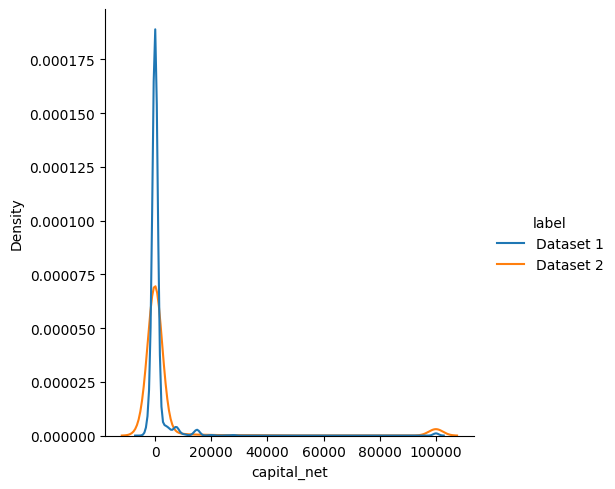

In [69]:
import seaborn as sns
df_reset_copy__ = df_reset_copy_.copy()
synthetic_data_ = synthetic_data_.copy()
df_reset_copy__['label'] = 'Dataset 1'
synthetic_data_['label'] = 'Dataset 2'

combined_data = pd.concat([df_reset_copy__, synthetic_data_], ignore_index=True)

sns.displot(combined_data, x="capital_net", kind="kde", hue='label')

In [70]:
df_reset_copy_ = df_reset_copy_.drop('capital_net_log', axis=1)
df_reset_copy_ = df_reset_copy_.drop('fnlwgt', axis=1)

synthetic_data_ = synthetic_data_.drop('capital_net_log', axis=1)
synthetic_data_ = synthetic_data_.drop('label', axis=1)



In [71]:
df_reset_copy_.to_csv("adult-data-census-complete.csv", index=False)

In [72]:
data = connector.read(
    folder_name='',
    file_names=['adult-data-census-complete.csv'],
    read_csv_parameters={
        'parse_dates': False,
        'encoding':'latin-1'
    }
)

In [73]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(data)

metadata.visualize()
metadata.update_column(
    column_name='education_num',
    sdtype='numerical',
    table_name='adult-data-census-complete'
)

metadata.validate()


In [74]:
metadata_dict = metadata.to_dict()
metadata_dict['columns'] = metadata_dict['tables']['adult-data-census-complete']['columns']

In [75]:
from sdmetrics.reports.single_table import QualityReport

report = QualityReport()
report.generate(df_reset_copy_, synthetic_data_, metadata_dict)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 83.49it/s]|
Column Shapes Score: 81.05%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 69.24it/s]|
Column Pair Trends Score: 68.59%

Overall Score (Average): 74.82%



In [76]:
column_shapes = report.get_details(property_name='Column Shapes')

In [77]:
column_shapes

,Column,Metric,Score
0,age,KSComplement,0.799453
1,workclass,TVComplement,0.854765
2,education_num,KSComplement,0.865391
3,marital_status,TVComplement,0.805166
4,occupation,TVComplement,0.820859
5,relationship,TVComplement,0.798563
6,race,TVComplement,0.984061
7,sex,TVComplement,0.994196
8,hours_per_week,KSComplement,0.896195
9,native_country,TVComplement,0.514788


In [78]:
from sdmetrics.reports.single_table import DiagnosticReport

report1 = DiagnosticReport()
report1.generate(df_reset_copy_, synthetic_data_, metadata_dict)

/usr/local/lib/python3.12/dist-packages/sdmetrics/reports/single_table/__init__.py:17: FutureWarning: The single table diagnostic report is deprecated. Please use the DiagnosticReport from 'sdmetrics.reports' instead.
  from sdmetrics.reports.single_table.diagnostic_report import DiagnosticReport


Generating report ...

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 163.07it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 279.45it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%



In [79]:
report1.get_details(
    property_name='Data Validity',
)

,Column,Metric,Score
0,age,BoundaryAdherence,1.0
1,workclass,CategoryAdherence,1.0
2,education_num,BoundaryAdherence,1.0
3,marital_status,CategoryAdherence,1.0
4,occupation,CategoryAdherence,1.0
5,relationship,CategoryAdherence,1.0
6,race,CategoryAdherence,1.0
7,sex,CategoryAdherence,1.0
8,hours_per_week,BoundaryAdherence,1.0
9,native_country,CategoryAdherence,1.0


In [80]:
from sdmetrics.reports.single_table import QualityReport

report2 = QualityReport()
report2.generate(df_reset_copy_, synthetic_data_, metadata_dict)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 83.74it/s]|
Column Shapes Score: 81.05%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 67.67it/s]|
Column Pair Trends Score: 68.59%

Overall Score (Average): 74.82%



In [81]:
score_value_fidelity = round(report2.get_score(), ndigits=4) * 0.75 +  round(report1.get_score(), ndigits=4) * 0.25
score_value_fidelity = float(score_value_fidelity * 100)

In [82]:
score_value_fidelity

81.11500000000001

In [83]:
report.get_properties()

,Property,Score
0,Column Shapes,0.810520
1,Column Pair Trends,0.685879


In [84]:
df_reset_copy_2 = df_reset_copy_.copy()

In [85]:
column_shapes

,Column,Metric,Score
0,age,KSComplement,0.799453
1,workclass,TVComplement,0.854765
2,education_num,KSComplement,0.865391
3,marital_status,TVComplement,0.805166
4,occupation,TVComplement,0.820859
5,relationship,TVComplement,0.798563
6,race,TVComplement,0.984061
7,sex,TVComplement,0.994196
8,hours_per_week,KSComplement,0.896195
9,native_country,TVComplement,0.514788


In [86]:
!pip install seaborn

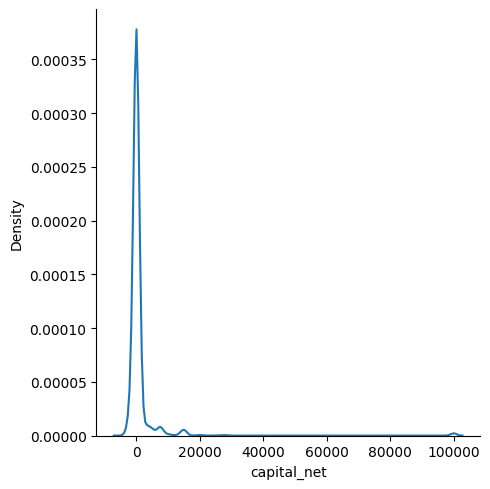

In [87]:
import seaborn as sns

sns.displot(df_reset_copy_2, x="capital_net", kind="kde")

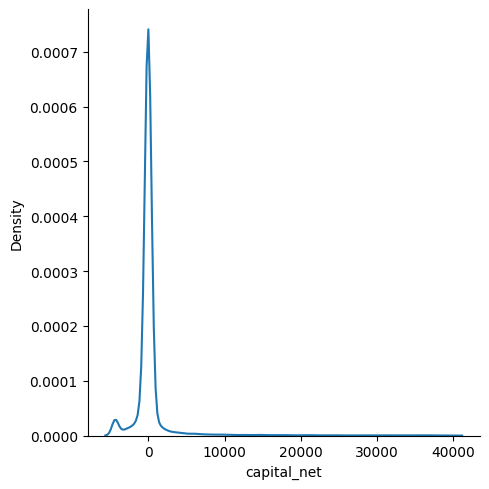

In [88]:
import seaborn as sns

sns.displot(synthetic_data_[synthetic_data_['capital_net']<=40000], x="capital_net", kind="kde")

Although in some of our tests, separate capital_gain and capital_loss provided better values (> higher than 0.9), we tested and the models provided worse results, so we decided to keep the them merged into a single column, capital_net. And they provided a worst result in terms of DQS.

We sensed that capital_loss is zero, when capital_gain > 0, and capital_gain is zero, when capital_loss > 0, so we can create a new column called capital_net, which is the difference between capital_gain and capital_loss, and then we can drop the two columns. This helped the dataset create a more better distribution. We obtained the value of 0.528946 for capital_net.

For capital_net, the distribution of around zero (-500, 500) is roughly the same as across the real dataset (0.904 for synthetic, and 0.87 for real), and the subsequent drop in frequency of higher values in the synthetic dataset is more uniform and linear compared to the real data. The real dataset has "up and down" fluctuations, around 2 fluctuations around (0, 20000) and another one around 100000. 

Column shapes, mainly measure differences in distribution between the real and synthetic datasets. For most columns we have values that are okay (>0.8), but for some columns such as 'capital_net', the values are low, for example 0.485949 and 'age', which it is 0.736617.  It can be seen that for 'capital_net', here is a very high peak at 0, and the high values are very rare, and there is an outlier at 1000000, but for synthetic data, the values are concentrated around values closer to zero, while never a value of zero, and then decreases sharply.

Before these comparisons, for 'capital_net_log', there were higher outliers than in the real dataset, and in order to mantain a fidelity to the real dataset, we capped them at the maximum of the real dataset, same happen for values lower than in the real dataset.
The same happened for 'capital_net' when we transformed the 'capital_net_log' back to 'capital_net' using the exponential function, we used the same capping technique to avoid outliers in the synthetic dataset. This helped us mantain a higher score for fidelity in 'Data Validity' section.

KSComplement measuring using Kolmogorov-Smirnov the similarity in terms of distribution between the real and synthetic datasets, used for numerical and datetime columns. TVComplement, measuring using Total Variation Distance, the same similarity as KSComplement, but for categorical columns.

In order to improve these results, we want to help the learn the heavy skewed distribution of capital_net for the synthetic dataset and after the synthetic dataset is generated, we reverse it back to the original distribution. But now there are a lot of values in the synthetic data that are gathered around 0 for the capital_net column, while having few outliers.

In [89]:
target_column = 'income'
df_reset_copy_ = df_reset_copy_2.copy()

In [90]:
from sklearn.model_selection import train_test_split
x_train_real, x_test_real, y_train_real, y_test_real = train_test_split(df_reset_copy_.copy().loc[:, df_reset_copy_.columns != target_column], df_reset_copy_.copy().loc[:, df_reset_copy_.columns == target_column], test_size=0.2, random_state=42)
x_train_syn, x_test_syn, y_train_syn, y_test_syn = train_test_split(synthetic_data_.copy().loc[:, synthetic_data_.columns != target_column], synthetic_data_.copy().loc[:, synthetic_data_.columns == target_column], test_size=0.2, random_state=42)

In [91]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded_y_train = encoder.fit_transform(y_train_real)
one_hot_df_y_train = pd.DataFrame(one_hot_encoded_y_train,  columns=encoder.get_feature_names_out(y_train_real.columns), index= y_train_real.index)
y_train_real = pd.concat([one_hot_df_y_train], axis=1)


In [92]:
y_test_real_copy = y_test_real.copy()

In [93]:
one_hot_encoded_y_test = encoder.transform(y_test_real)
one_hot_df_y_test = pd.DataFrame(one_hot_encoded_y_test,  columns=encoder.get_feature_names_out(y_test_real.columns), index= y_test_real.index)
y_test_real = pd.concat([one_hot_df_y_test], axis=1)

In [94]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded_y_train_syn = encoder.fit_transform(y_train_syn)
one_hot_df_y_train_syn = pd.DataFrame(one_hot_encoded_y_train_syn,  columns=encoder.get_feature_names_out(y_train_syn.columns), index= y_train_syn.index)
y_train_syn = pd.concat([one_hot_df_y_train_syn], axis=1)

one_hot_encoded_y_test_syn = encoder.transform(y_test_syn)
one_hot_df_y_test_syn = pd.DataFrame(one_hot_encoded_y_test_syn,  columns=encoder.get_feature_names_out(y_test_syn.columns), index= y_test_syn.index)
y_test_syn = pd.concat([one_hot_df_y_test_syn], axis=1)

one_hot_encoded_y_test_copy = encoder.transform(y_test_real_copy)
one_hot_df_y_test_copy = pd.DataFrame(one_hot_encoded_y_test_copy,  columns=encoder.get_feature_names_out(y_test_real_copy.columns), index= y_test_real_copy.index)
y_test_real_copy = pd.concat([one_hot_df_y_test_copy], axis=1)

In [95]:
is_col_OH.remove(target_column)


In [96]:
x_test_real_copy = x_test_real.copy() 

In [97]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded_x_train = encoder.fit_transform(x_train_real[is_col_OH])
one_hot_df_x_train = pd.DataFrame(one_hot_encoded_x_train,  columns=encoder.get_feature_names_out(is_col_OH), index= x_train_real.index)
x_train_real = pd.concat([x_train_real.drop(is_col_OH, axis=1), one_hot_df_x_train], axis=1)

one_hot_encoded_x_test = encoder.transform(x_test_real[is_col_OH])
one_hot_df_x_test = pd.DataFrame(one_hot_encoded_x_test,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_real.index)
x_test_real = pd.concat([x_test_real.drop(is_col_OH, axis=1), one_hot_df_x_test], axis=1)


In [98]:
one_hot_encoded_x_train_syn = encoder.transform(x_train_syn[is_col_OH])
one_hot_df_x_train_syn = pd.DataFrame(one_hot_encoded_x_train_syn,  columns=encoder.get_feature_names_out(is_col_OH), index= x_train_syn.index)
x_train_syn = pd.concat([x_train_syn.drop(is_col_OH, axis=1), one_hot_df_x_train_syn], axis=1)

one_hot_encoded_x_test_syn = encoder.transform(x_test_syn[is_col_OH])
one_hot_df_x_test_syn = pd.DataFrame(one_hot_encoded_x_test_syn,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_syn.index)
x_test_syn = pd.concat([x_test_syn.drop(is_col_OH, axis=1), one_hot_df_x_test_syn], axis=1)

one_hot_encoded_x_test_copy = encoder.transform(x_test_real_copy[is_col_OH])
one_hot_df_x_test_copy = pd.DataFrame(one_hot_encoded_x_test_copy,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_real_copy.index)
x_test_real_copy = pd.concat([x_test_real_copy.drop(is_col_OH, axis=1), one_hot_df_x_test_copy], axis=1)

In [99]:
from scipy.stats import chi2_contingency
correlated_values_2 = {}
correlated_values_3 = {}

highest_corr_values = []
correlated_columns = set()
value_cosine_similarity = {}
for idx_col_cat in range(len(encoder.get_feature_names_out(is_col_OH))):

    for idx_col_cat_2 in range(idx_col_cat+1, len(encoder.get_feature_names_out(is_col_OH))):
        col_cat = encoder.get_feature_names_out(is_col_OH)[idx_col_cat]
        
        col_cat_2 = encoder.get_feature_names_out(is_col_OH)[idx_col_cat_2]

        
        
        contingency_table = pd.crosstab(x_train_syn[col_cat], x_train_syn[col_cat_2])
        chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
        n = contingency_table.sum().sum()
        phi2 = chi2_statistic / n
        r, k = contingency_table.shape
        if n == 1:
            v = 0
        else: 
            phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
            k_corr = k - (k - 1) * (k - 2) / (n - 1)
            r_corr = r - (r - 1) * (r - 2) / (n - 1)
            if k_corr == 1 and r_corr == 1:
                v = 0
            elif k_corr != 1 and r_corr==1:
                v = np.sqrt(phi2corr/(k_corr-1))
            elif r_corr != 1 and k_corr == 1:
                v = np.sqrt(phi2corr/(r_corr-1))
            else:
                v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))
        
        

        if v > 0.5:
            print("v=", v, " col_cat=", col_cat, " col_cat_2=", col_cat_2)
            

        
        if v > 0.6:
            
            if (col_cat, col_cat_2) not in correlated_columns or (col_cat_2, col_cat) not in correlated_columns:
                correlated_columns.add((col_cat, col_cat_2))
            if col_cat in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat]
                list_cat_2 = correlated_values_3[col_cat]
                list_cat.append((float(v), col_cat_2))
                list_cat_2.append(col_cat_2)
                correlated_values_2[col_cat] = list_cat
                correlated_values_3[col_cat] = list_cat_2

            else:
                correlated_values_2[col_cat] = [(float(v), col_cat_2)]
                correlated_values_3[col_cat] = [col_cat_2]
            
            if col_cat_2 in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat_2]
                list_cat_2 = correlated_values_3[col_cat_2]
                list_cat.append((float(v), col_cat))
                list_cat_2.append(col_cat)
                correlated_values_2[col_cat_2] = list_cat
                correlated_values_3[col_cat_2] = list_cat_2
            else:
                correlated_values_2[col_cat_2] = [(float(v), col_cat)]
                correlated_values_3[col_cat_2] = [col_cat]
      

v= 0.6541379769842917  col_cat= workclass_Private  col_cat_2= workclass_Self-emp-inc
v= 0.5581289420949905  col_cat= marital_status_Divorced  col_cat_2= relationship_Unmarried
v= 0.8046056184253013  col_cat= marital_status_Married-civ-spouse  col_cat_2= marital_status_Never-married
v= 0.6750538313067334  col_cat= marital_status_Married-civ-spouse  col_cat_2= relationship_Husband
v= 0.7011797608364403  col_cat= marital_status_Married-civ-spouse  col_cat_2= relationship_Not-in-family
v= 0.5431950698919896  col_cat= marital_status_Never-married  col_cat_2= relationship_Husband
v= 0.5279039068830564  col_cat= marital_status_Never-married  col_cat_2= relationship_Not-in-family
v= 0.5984167262057947  col_cat= marital_status_Never-married  col_cat_2= relationship_Own-child
v= 0.6434673498399884  col_cat= relationship_Husband  col_cat_2= sex_Female
v= 0.6434673498399884  col_cat= relationship_Husband  col_cat_2= sex_Male
v= 0.7012854317038344  col_cat= relationship_Wife  col_cat_2= sex_Female


In [100]:
if len(y_train_real.columns) == 2 and target_column not in y_train_real.columns:
    y_train_real = y_train_real.drop(y_train_real.columns[0], axis=1)
    y_test_real = y_test_real.drop(y_test_real.columns[0], axis=1)
    y_test_real_copy = y_test_real_copy.drop(y_test_real_copy.columns[0], axis=1)
    y_train_syn = y_train_syn.drop(y_train_syn.columns[0], axis=1)
    y_test_syn = y_test_syn.drop(y_test_syn.columns[0], axis=1)

We use logistic regression, random forest, SVM, KNN and Decision Tree Classifier to evaluate the performance of the synthetic dataset, and we compare it with a real dataset. 


In [101]:
!pip install great_tables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.4/495.4 kB 28.3 MB/s eta 0:00:00


In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, average_precision_score


model = LogisticRegression(max_iter=10000, n_jobs=-1, C=0.1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

Accuracy of Logistic Regression model is: 78.85766927683096 %
ROC of Logistic Regression model is: 74.34526310420483 %
Precision of Logistic Regression model is: 55.192719486081366 %
Recall of Logistic Regression model is: 65.62698917886696 %
AUPRC of Logistic Regression model is: 44.51243013217029 %


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [103]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=10000, C=0.1"
type_ = "synthetic"
values_dict = {}
values_dict["model_name"] = []
values_dict["data_type"] = []
values_dict["hyper_parameters"] = []
values_dict["accuracy"] = []
values_dict["precision"] = []
values_dict["recall"] = []
values_dict["roc_auc"] = []
values_dict["auprc"] = []

values_dict["data_type"].append(type_)
values_dict["model_name"].append(model_name)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, average_precision_score


model = LogisticRegression(max_iter=10000, n_jobs=-1, C=1.0, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

Accuracy of Logistic Regression model is: 78.15138952863504 %
ROC of Logistic Regression model is: 74.20550698735504 %
Precision of Logistic Regression model is: 53.80658436213992 %
Recall of Logistic Regression model is: 66.58179503500955 %
AUPRC of Logistic Regression model is: 43.88619118931463 %


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [105]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=10000, C=1.0"
type_ = "synthetic"
values_dict["data_type"].append(type_)
values_dict["model_name"].append(model_name)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, average_precision_score


model = LogisticRegression(max_iter=500, n_jobs=-1, C=0.1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

Accuracy of Logistic Regression model is: 78.41240595731614 %
ROC of Logistic Regression model is: 74.18211662670812 %
Precision of Logistic Regression model is: 54.321634363541115 %
Recall of Logistic Regression model is: 66.008911521324 %
AUPRC of Logistic Regression model is: 44.056106206067405 %


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [107]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=500, C=0.1"
type_ = "synthetic"
values_dict["data_type"].append(type_)
values_dict["model_name"].append(model_name)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, average_precision_score


model = LogisticRegression(max_iter=2500, n_jobs=-1, C=0.1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

Accuracy of Logistic Regression model is: 78.02855826807922 %
ROC of Logistic Regression model is: 74.29824410005203 %
Precision of Logistic Regression model is: 53.55691056910569 %
Recall of Logistic Regression model is: 67.09102482495226 %
AUPRC of Logistic Regression model is: 43.86985037881549 %


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [109]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=2500, C=0.1"
type_ = "synthetic"
values_dict["data_type"].append(type_)
values_dict["model_name"].append(model_name)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [110]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(max_iter=10000, n_jobs=-1, C=10.0, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of Logistic Regression model is: 84.99923230462153 %
ROC of Logistic Regression model is: 76.30809561505443 %
Precision of Logistic Regression model is: 73.27586206896551 %
Recall of Logistic Regression model is: 59.516231699554424 %
AUPRC of Logistic Regression model is: 53.37611706299844 %


In [111]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=10000, C=10.0"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [112]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(max_iter=50, n_jobs=-1, C=0.1, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of Logistic Regression model is: 80.0092123445417 %
ROC of Logistic Regression model is: 68.30899155860432 %
Precision of Logistic Regression model is: 61.52527849185947 %
Recall of Logistic Regression model is: 45.70337364735837 %
AUPRC of Logistic Regression model is: 41.21601107347574 %


In [113]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=50, C=0.1"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [114]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [115]:
!pip install polars
!pip install great_tables

In [116]:
model = RandomForestClassifier(max_depth=10, max_samples=0.9, n_estimators=200, n_jobs=-1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=50, n_jobs=-1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_2 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


Accuracy of RandomForestClassifier model is: 81.34500230308613 %
ROC of RandomForestClassifier model is: 73.98700160564007 %
Precision of RandomForestClassifier model is: 61.69513797634691 %
Recall of RandomForestClassifier model is: 59.770846594525786 %
AUPRC of RandomForestClassifier model is: 46.579375860032435 %
 
Accuracy of RandomForestClassifier model is: 80.93044679871028 %
ROC of RandomForestClassifier model is: 73.47502834278006 %
Precision of RandomForestClassifier model is: 60.772757039947614 %
Recall of RandomForestClassifier model is: 59.070655633354555 %
AUPRC of RandomForestClassifier model is: 45.77142859713603 %


In [117]:
model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.9, n_estimators=200"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=50, max_samples=0.8, n_estimators=50"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

In [118]:
model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=100, n_jobs=-1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_2 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print(" ")

model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=200, n_jobs=-1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_3 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")


Accuracy of RandomForestClassifier model is: 81.16075541225241 %
ROC of RandomForestClassifier model is: 73.80046476749646 %
Precision of RandomForestClassifier model is: 61.25654450261781 %
Recall of RandomForestClassifier model is: 59.57988542329726 %
AUPRC of RandomForestClassifier model is: 46.24631033554832 %
 
Accuracy of RandomForestClassifier model is: 81.25287885766927 %
ROC of RandomForestClassifier model is: 73.79604043441155 %
Precision of RandomForestClassifier model is: 61.54353562005277 %
Recall of RandomForestClassifier model is: 59.38892425206874 %
AUPRC of RandomForestClassifier model is: 46.345836780764046 %


In [119]:
model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.8, n_estimators=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.8, n_estimators=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))

In [120]:
model = RandomForestClassifier(max_depth=100, max_samples=0.5, n_estimators=200, n_jobs=-1, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


print(" ")
model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=100, n_jobs=-1, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred_2 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


Accuracy of RandomForestClassifier model is: 85.81298940580378 %
ROC of RandomForestClassifier model is: 78.14688579759455 %
Precision of RandomForestClassifier model is: 74.08786299329859 %
Recall of RandomForestClassifier model is: 63.33545512412476 %
AUPRC of RandomForestClassifier model is: 55.76773597856209 %
 
Accuracy of RandomForestClassifier model is: 85.7976354982343 %
ROC of RandomForestClassifier model is: 75.35795237485577 %
Precision of RandomForestClassifier model is: 79.6875 %
Recall of RandomForestClassifier model is: 55.18777848504137 %
AUPRC of RandomForestClassifier model is: 54.78691190917875 %


In [121]:
model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=100, max_samples=0.5, n_estimators=200"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict['auprc'].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.8, n_estimators=100"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict['auprc'].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


In [122]:
model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=200, n_jobs=-1, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred_2 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


Accuracy of RandomForestClassifier model is: 85.78228159066482 %
ROC of RandomForestClassifier model is: 75.32612551298435 %
Precision of RandomForestClassifier model is: 79.6688132474701 %
Recall of RandomForestClassifier model is: 55.12412476129853 %
AUPRC of RandomForestClassifier model is: 54.74124084686224 %


In [123]:
model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.8, n_estimators=200"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict['auprc'].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


In [124]:
from sklearn import svm

model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=10000, decision_function_shape="ovr"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of Logistic Regression model is: 77.52187931828651 %
ROC of Logistic Regression model is: 57.61711731322037 %
Precision of Logistic Regression model is: 60.80808080808081 %
Recall of Logistic Regression model is: 19.159770846594526 %
AUPRC of Logistic Regression model is: 31.15015155227538 %
 


In [125]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=10000, decision_function_shape=ovr"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [126]:
from sklearn import svm

model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=5000, decision_function_shape="ovo"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of Logistic Regression model is: 22.063565177337633 %
ROC of Logistic Regression model is: 45.713491008750516 %
Precision of Logistic Regression model is: 22.51842559197115 %
Recall of Logistic Regression model is: 91.40674729471674 %
AUPRC of Logistic Regression model is: 22.65613789748121 %
 


In [127]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=5000, decision_function_shape=ovo"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [128]:
from sklearn import svm

model_simple = svm.SVC(
    random_state=42, C=1.0, max_iter=10000, decision_function_shape="ovo"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")
model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=1500, decision_function_shape="ovo"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


print(" ")
model_simple = svm.SVC(
    random_state=42, C=100.0, max_iter=6330, decision_function_shape="ovr"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_3 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of Logistic Regression model is: 78.39705204974666 %
ROC of Logistic Regression model is: 57.716197902028895 %
Precision of Logistic Regression model is: 70.81218274111674 %
Recall of Logistic Regression model is: 17.759388924252068 %
AUPRC of Logistic Regression model is: 32.41305951851057 %
 


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 22.094272992476586 %
ROC of svm.SVC model is: 45.777144732493355 %
Precision of svm.SVC model is: 22.54271829440351 %
Recall of svm.SVC model is: 91.53405474220241 %
AUPRC of svm.SVC model is: 22.676333810720152 %
 


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=6330).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 23.384001228312606 %
ROC of svm.SVC model is: 48.45060112969259 %
Precision of svm.SVC model is: 23.549435246789415 %
Recall of svm.SVC model is: 96.88096753660089 %
AUPRC of svm.SVC model is: 23.567262187399248 %


In [129]:
model_name = "svm.SVC"
hyper_parameters = "C=1.0, max_iter=10000, decision_function_shape=ovr"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=1500, decision_function_shape=ovo"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


model_name = "svm.SVC"
hyper_parameters = "C=100.0, max_iter=6330, decision_function_shape=ovr"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))


In [130]:
model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=10000, decision_function_shape="ovr"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

Accuracy of svm.SVC model is: 80.74619990787656 %
ROC of svm.SVC model is: 62.933059776024415 %
Precision of svm.SVC model is: 77.37478411053542 %
Recall of svm.SVC model is: 28.516868236791854 %
AUPRC of svm.SVC model is: 39.30730343382558 %


In [131]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=10000, decision_function_shape=ovr"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))



In [132]:
model_simple = svm.SVC(
    random_state=42, C=1.0, max_iter=10000, decision_function_shape="ovr"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

Accuracy of svm.SVC model is: 80.66943037002918 %
ROC of svm.SVC model is: 62.88247296906366 %
Precision of svm.SVC model is: 76.71232876712328 %
Recall of svm.SVC model is: 28.516868236791854 %
AUPRC of svm.SVC model is: 39.11839191641715 %


In [133]:
model_name = "svm.SVC"
hyper_parameters = "C=1.0, max_iter=10000, decision_function_shape=ovr"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))



In [134]:
model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=5000, decision_function_shape="ovr"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 21.387993244280672 %
ROC of svm.SVC model is: 44.291399585928794 %
Precision of svm.SVC model is: 21.971252566735114 %
Recall of svm.SVC model is: 88.542329726289 %
AUPRC of svm.SVC model is: 22.217562255140095 %


In [135]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=5000, decision_function_shape=ovr"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))



In [136]:
model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=5375, decision_function_shape="ovr"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

print(" ")
model_simple = svm.SVC(
    random_state=42, C=0.1, max_iter=500, decision_function_shape="ovo"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred_3 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5375).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 80.37770612620912 %
ROC of svm.SVC model is: 63.51520412082512 %
Precision of svm.SVC model is: 71.5758468335788 %
Recall of svm.SVC model is: 30.935709739019735 %
AUPRC of svm.SVC model is: 38.80148593256321 %
 


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 19.83724857976355 %
ROC of svm.SVC model is: 40.838082031643445 %
Precision of svm.SVC model is: 20.602448453608247 %
Recall of svm.SVC model is: 81.41311266709103 %
AUPRC of svm.SVC model is: 21.256435582002553 %


In [137]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=5375, decision_function_shape=ovr"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

model_name = "svm.SVC"
hyper_parameters = "C=0.1, max_iter=500, decision_function_shape=ovo"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))


In [138]:
is_col_numeric.remove("capital_gain")
is_col_numeric.remove("capital_loss")
is_col_numeric.append("capital_net")

In [139]:
x_train_syn_copy = x_train_syn.copy()
x_test_syn_copy = x_test_syn.copy()

x_train_real_copy = x_train_real.copy()
x_test_real_copy = x_test_real.copy()

In [140]:
y_train_syn_copy = y_train_syn.copy()
y_test_syn_copy = y_test_syn.copy()

y_train_real_copy = y_train_real.copy()
y_test_real_copy = y_test_real.copy()

In [141]:
is_col_numeric.remove("fnlwgt")

In [142]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train_syn[is_col_numeric])
x_train_syn_scaled = scaler.transform(x_train_syn[is_col_numeric])
x_test_syn_scaled = scaler.transform(x_test_syn[is_col_numeric])
x_test_real_scaled = scaler.transform(x_test_real[is_col_numeric])
x_train_real_scaled = scaler.transform(x_train_real[is_col_numeric])

In [143]:
x_test_real_copy[is_col_numeric] = x_test_real_scaled
x_train_real_copy[is_col_numeric] = x_train_real_scaled
x_train_syn_copy[is_col_numeric] = x_train_syn_scaled
x_test_syn_copy[is_col_numeric] = x_test_syn_scaled

Precision and recall produce nan values for knn neighbors classifier, so we do not use them.

In [144]:
model_simple = KNeighborsClassifier(n_neighbors=50, leaf_size=200)
model_simple.fit(x_train_syn_scaled, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")
model_simple = KNeighborsClassifier(n_neighbors=200, leaf_size=200)
model_simple.fit(x_train_syn_scaled, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


Accuracy of KNeighborsClassifier model is: 73.62198679563949 %
ROC of KNeighborsClassifier model is: 60.127330631763854 %
Precision of KNeighborsClassifier model is: 43.960558751027115 %
Recall of KNeighborsClassifier model is: 34.05474220241884 %
AUPRC of KNeighborsClassifier model is: 30.877303195382744 %
 
Accuracy of KNeighborsClassifier model is: 73.43773990480578 %
ROC of KNeighborsClassifier model is: 60.071050796495875 %
Precision of KNeighborsClassifier model is: 43.56275303643724 %
Recall of KNeighborsClassifier model is: 34.24570337364736 %
AUPRC of KNeighborsClassifier model is: 30.778957705522014 %


In [145]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=50, leaf_size=200"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=200, leaf_size=200"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

In [146]:
model_simple = KNeighborsClassifier(n_neighbors=5, leaf_size=200)
model_simple.fit(x_train_syn_scaled, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

Accuracy of KNeighborsClassifier model is: 66.451711960694 %
ROC of KNeighborsClassifier model is: 60.222031968028354 %
Precision of KNeighborsClassifier model is: 35.57330827067669 %
Recall of KNeighborsClassifier model is: 48.18586887332909 %
AUPRC of KNeighborsClassifier model is: 29.639388438767217 %
 


In [147]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=5, leaf_size=200"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [148]:
model_simple = KNeighborsClassifier(n_neighbors=50, leaf_size=30)
model_simple.fit(x_train_real_scaled, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of KNeighborsClassifier model is: 79.8710271764164 %
ROC of KNeighborsClassifier model is: 61.357733154625485 %
Precision of KNeighborsClassifier model is: 73.89705882352942 %
Recall of KNeighborsClassifier model is: 25.58879694462126 %
AUPRC of KNeighborsClassifier model is: 36.85808627911822 %


In [149]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=50, leaf_size=30"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [150]:
model_simple = KNeighborsClassifier(n_neighbors=5, leaf_size=200)
model_simple.fit(x_train_real_scaled, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of KNeighborsClassifier model is: 76.86166129279903 %
ROC of KNeighborsClassifier model is: 63.45611641186716 %
Precision of KNeighborsClassifier model is: 52.867383512544805 %
Recall of KNeighborsClassifier model is: 37.55569700827498 %
AUPRC of KNeighborsClassifier model is: 34.91689769383043 %


In [151]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=5, leaf_size=200"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [152]:
model_simple = KNeighborsClassifier(n_neighbors=200, leaf_size=50)
model_simple.fit(x_train_real_scaled, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of KNeighborsClassifier model is: 78.61200675571934 %
ROC of KNeighborsClassifier model is: 57.59732695576775 %
Precision of KNeighborsClassifier model is: 75.0 %
Recall of KNeighborsClassifier model is: 16.995544239338003 %
AUPRC of KNeighborsClassifier model is: 32.768153650100764 %


In [153]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=200, leaf_size=50"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [154]:
model_simple = KNeighborsClassifier(n_neighbors=50, leaf_size=2)
model_simple.fit(x_train_real_scaled, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

Accuracy of KNeighborsClassifier model is: 79.79425763856901 %
ROC of KNeighborsClassifier model is: 60.807827836641515 %
Precision of KNeighborsClassifier model is: 75.3479125248509 %
Recall of KNeighborsClassifier model is: 24.124761298535965 %
AUPRC of KNeighborsClassifier model is: 36.479361862865865 %


In [155]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=50, leaf_size=2"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


In [156]:
from sklearn.tree import DecisionTreeClassifier

In [157]:
model_simple = DecisionTreeClassifier(criterion='entropy', min_samples_split=50, min_samples_leaf=100)
model_simple.fit(x_train_syn, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

Accuracy of DecisionTreeClassifier model is: 80.76155381544604 %
ROC of DecisionTreeClassifier model is: 72.53877634925414 %
Precision of DecisionTreeClassifier model is: 60.87551299589603 %
Recall of DecisionTreeClassifier model is: 56.65181413112666 %
AUPRC of DecisionTreeClassifier model is: 44.94309352861833 %
 


In [158]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='entropy', min_samples_split=50, min_samples_leaf=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [159]:
model_simple = DecisionTreeClassifier(criterion='gini', min_samples_split=20, min_samples_leaf=100)
model_simple.fit(x_train_syn, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

Accuracy of DecisionTreeClassifier model is: 80.79226163058499 %
ROC of DecisionTreeClassifier model is: 72.5807205725177 %
Precision of DecisionTreeClassifier model is: 60.94391244870041 %
Recall of DecisionTreeClassifier model is: 56.71546785486951 %
AUPRC of DecisionTreeClassifier model is: 45.00528222158648 %
 


In [160]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='gini', min_samples_split=20, min_samples_leaf=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [161]:
model_simple = DecisionTreeClassifier(criterion='log_loss', min_samples_split=20, min_samples_leaf=100)
model_simple.fit(x_train_syn, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print(" ")
model_simple = DecisionTreeClassifier(criterion='log_loss', min_samples_split=2, min_samples_leaf=1)
model_simple.fit(x_train_syn, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

Accuracy of DecisionTreeClassifier model is: 80.79226163058499 %
ROC of DecisionTreeClassifier model is: 72.55901107203843 %
Precision of DecisionTreeClassifier model is: 60.95890410958904 %
Recall of DecisionTreeClassifier model is: 56.65181413112666 %
AUPRC of DecisionTreeClassifier model is: 44.99033610734957 %
 
Accuracy of DecisionTreeClassifier model is: 72.59327498848457 %
ROC of DecisionTreeClassifier model is: 66.2879600694601 %
Precision of DecisionTreeClassifier model is: 44.40961337513062 %
Recall of DecisionTreeClassifier model is: 54.10566518141311 %
AUPRC of DecisionTreeClassifier model is: 35.098284078700736 %


In [162]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='log_loss', min_samples_split=20, min_samples_leaf=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='log_loss', min_samples_split=2, min_samples_leaf=1"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


In [163]:
model_simple = DecisionTreeClassifier(criterion='entropy', min_samples_split=50, min_samples_leaf=100)
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of DecisionTreeClassifier model is: 85.50591125441424 %
ROC of DecisionTreeClassifier model is: 75.94726452565868 %
Precision of DecisionTreeClassifier model is: 76.59033078880407 %
Recall of DecisionTreeClassifier model is: 57.47931253978358 %
AUPRC of DecisionTreeClassifier model is: 54.28000586576104 %


In [164]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='entropy', min_samples_split=50, min_samples_leaf=100"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [165]:
model_simple = DecisionTreeClassifier(criterion='gini', min_samples_split=200, min_samples_leaf=1)
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

print(" ")


Accuracy of DecisionTreeClassifier model is: 86.19683709504069 %
ROC of DecisionTreeClassifier model is: 77.90050132137506 %
Precision of DecisionTreeClassifier model is: 76.41509433962264 %
Recall of DecisionTreeClassifier model is: 61.87141947803947 %
AUPRC of DecisionTreeClassifier model is: 56.476094197523906 %
 


In [166]:
model_simple = DecisionTreeClassifier(criterion='entropy', min_samples_split=50, min_samples_leaf=100)
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred_3 = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")


Accuracy of DecisionTreeClassifier model is: 85.50591125441424 %
ROC of DecisionTreeClassifier model is: 75.94726452565868 %
Precision of DecisionTreeClassifier model is: 76.59033078880407 %
Recall of DecisionTreeClassifier model is: 57.47931253978358 %
AUPRC of DecisionTreeClassifier model is: 54.28000586576104 %


In [167]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='gini', min_samples_split=200, min_samples_leaf=1"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='entropy', min_samples_split=50, min_samples_leaf=10"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))

In [168]:
model_simple = svm.SVC(C=10.0, max_iter=5000, decision_function_shape="ovo")
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print(" ")

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 21.387993244280672 %
ROC of svm.SVC model is: 77.90050132137506 %
Precision of svm.SVC model is: 21.971252566735114 %
Recall of svm.SVC model is: 88.542329726289 %
AUPRC of svm.SVC model is: 22.217562255140095 %
 


In [169]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=5000, decision_function_shape='ovo'"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [170]:
table_element_real = pd.DataFrame({'model_name': values_dict['model_name'], 'data_type':values_dict['data_type'], 'hyper_parameters': values_dict['hyper_parameters'], 'accuracy':values_dict['accuracy'], 'precision':values_dict['precision'], 'recall':values_dict['recall'], 'auprc':values_dict['auprc'] ,'roc_auc':values_dict['roc_auc']})

In [171]:
table_element_real

,model_name,data_type,hyper_parameters,accuracy,precision,recall,auprc,roc_auc
0,LogisticRegression,synthetic,"max_iter=10000, C=0.1",0.788577,0.551927,0.656270,0.445124,0.743453
1,LogisticRegression,synthetic,"max_iter=10000, C=1.0",0.781514,0.538066,0.665818,0.438862,0.742055
2,LogisticRegression,synthetic,"max_iter=500, C=0.1",0.784124,0.543216,0.660089,0.440561,0.741821
3,LogisticRegression,synthetic,"max_iter=2500, C=0.1",0.780286,0.535569,0.670910,0.438699,0.742982
4,LogisticRegression,real,"max_iter=10000, C=10.0",0.849992,0.732759,0.595162,0.533761,0.763081
5,LogisticRegression,real,"max_iter=50, C=0.1",0.800092,0.615253,0.457034,0.412160,0.683090
6,RandomForestClassifier,synthetic,"max_depth=10, max_samples=0.9, n_estimators=200",0.813450,0.616951,0.597708,0.465794,0.739870
7,RandomForestClassifier,synthetic,"max_depth=50, max_samples=0.8, n_estimators=50",0.809304,0.607728,0.590707,0.457714,0.734750
8,RandomForestClassifier,synthetic,"max_depth=10, max_samples=0.8, n_estimators=100",0.811608,0.612565,0.595799,0.462463,0.738005
9,RandomForestClassifier,synthetic,"max_depth=10, max_samples=0.8, n_estimators=100",0.812529,0.615435,0.593889,0.463458,0.737960


In [172]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element_real = table_element_real.sort_values(by=['model_name', 'auprc', 'data_type'], ascending=False, ignore_index=True)

gt_table_element = GT(table_element_real)
location_list = []
for idx, elements in enumerate(table_element_real.columns):
    if "accuracy" in elements or "precision" in elements or "auprc" in elements or "recall" in elements or "roc_auc" in elements:
        pos_min, pos_max = (np.argmin(table_element_real[elements]), np.argmax(table_element_real[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        


In [173]:
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
) 

model_name,data_type,hyper_parameters,accuracy,precision,recall,auprc,roc_auc
svm.SVC,real,"C=10.0, max_iter=10000, decision_function_shape=ovr",0.8074619990787656,0.7737478411053541,0.28516868236791854,0.3930730343382558,0.6293305977602441
svm.SVC,real,"C=1.0, max_iter=10000, decision_function_shape=ovr",0.8066943037002917,0.7671232876712328,0.28516868236791854,0.3911839191641715,0.6288247296906366
svm.SVC,real,"C=10.0, max_iter=5375, decision_function_shape=ovr",0.8037770612620913,0.7157584683357879,0.30935709739019734,0.38801485932563207,0.6351520412082512
svm.SVC,synthetic,"C=1.0, max_iter=10000, decision_function_shape=ovr",0.7839705204974666,0.7081218274111675,0.17759388924252067,0.32413059518510573,0.577161979020289
svm.SVC,synthetic,"C=10.0, max_iter=10000, decision_function_shape=ovr",0.775218793182865,0.6080808080808081,0.19159770846594526,0.3115015155227538,0.5761711731322037
svm.SVC,synthetic,"C=100.0, max_iter=6330, decision_function_shape=ovr",0.23384001228312606,0.23549435246789416,0.9688096753660089,0.23567262187399246,0.48450601129692594
svm.SVC,synthetic,"C=10.0, max_iter=1500, decision_function_shape=ovo",0.22094272992476585,0.2254271829440351,0.9153405474220242,0.22676333810720153,0.4577714473249336
svm.SVC,synthetic,"C=10.0, max_iter=5000, decision_function_shape=ovo",0.22063565177337632,0.22518425591971147,0.9140674729471674,0.22656137897481207,0.4571349100875052
svm.SVC,real,"C=10.0, max_iter=5000, decision_function_shape=ovr",0.2138799324428067,0.21971252566735114,0.8854232972628899,0.22217562255140094,0.4429139958592879
svm.SVC,real,"C=10.0, max_iter=5000, decision_function_shape='ovo'",0.2138799324428067,0.21971252566735114,0.8854232972628899,0.22217562255140094,0.4429139958592879


In [174]:
idx_list = []
for models in table_element_real['model_name'].unique():
    for data_type in table_element_real['data_type'].unique():
        idx_list.append(int(table_element_real[table_element_real['model_name']==models][table_element_real['data_type']==data_type]['auprc'].index[0]))

In [175]:
idx_list

[0, 3, 11, 14, 18, 19, 24, 28, 31, 34]

In [176]:
table_element_real_copy = table_element_real.copy()


In [177]:
table_element_real_copy = table_element_real_copy.loc[idx_list, :]

In [178]:
table_element_real_copy.index = list(range(len(idx_list)))

In [179]:
table_element_real_copy

,model_name,data_type,hyper_parameters,accuracy,precision,recall,auprc,roc_auc
0,svm.SVC,real,"C=10.0, max_iter=10000, decision_function_shap...",0.807462,0.773748,0.285169,0.393073,0.629331
1,svm.SVC,synthetic,"C=1.0, max_iter=10000, decision_function_shape...",0.783971,0.708122,0.177594,0.324131,0.577162
2,RandomForestClassifier,real,"max_depth=100, max_samples=0.5, n_estimators=200",0.858130,0.740879,0.633355,0.557677,0.781469
3,RandomForestClassifier,synthetic,"max_depth=10, max_samples=0.9, n_estimators=200",0.813450,0.616951,0.597708,0.465794,0.739870
4,LogisticRegression,real,"max_iter=10000, C=10.0",0.849992,0.732759,0.595162,0.533761,0.763081
5,LogisticRegression,synthetic,"max_iter=10000, C=0.1",0.788577,0.551927,0.656270,0.445124,0.743453
6,KNeighborsClassifier,real,"n_neighbors=50, leaf_size=30",0.798710,0.738971,0.255888,0.368581,0.613577
7,KNeighborsClassifier,synthetic,"n_neighbors=50, leaf_size=200",0.736220,0.439606,0.340547,0.308773,0.601273
8,DecisionTreeClassifier,real,"criterion='gini', min_samples_split=200, min_s...",0.861968,0.764151,0.618714,0.564761,0.779005
9,DecisionTreeClassifier,synthetic,"criterion='gini', min_samples_split=20, min_sa...",0.807923,0.609439,0.567155,0.450053,0.725807


Accuracy is not a good metric to measure the performance of the models, as it is not a good metric for imbalanced datasets, so we use roc_auc instead.

In [180]:
values_dict2 = {}
values_dict2["model_name"] = []
values_dict2["difference_between_data_type"] = []
values_dict2["percentage_reduction"] = []
values_dict2["synthetic_data_auprc"] = []
values_dict2["real_data_auprc"] = []


In [181]:
for _model_columns in table_element_real_copy["model_name"].unique():
    dif_in_percentage=table_element_real_copy[table_element_real_copy["model_name"]==_model_columns]
    dif_in_percentage_syn = table_element_real_copy[table_element_real_copy["model_name"]==_model_columns][table_element_real_copy["data_type"]=="synthetic"]
    dif_in_percentage_real = table_element_real_copy[table_element_real_copy["model_name"]==_model_columns][table_element_real_copy["data_type"]=="real"]

    dif_copy = dif_in_percentage_real["auprc"].to_list()[0]-dif_in_percentage_syn["auprc"].to_list()[0]
    dif_in_percentage_copy = (dif_in_percentage_real["auprc"].to_list()[0]-dif_in_percentage_syn["auprc"].to_list()[0])/dif_in_percentage_real["auprc"].to_list()[0]
    
    values_dict2["model_name"].append(_model_columns)
    values_dict2["difference_between_data_type"].append(dif_copy)
    values_dict2["percentage_reduction"].append(round(dif_in_percentage_copy*100, ndigits=2))
    values_dict2["synthetic_data_auprc"].append(dif_in_percentage_syn["auprc"].to_list()[0])
    values_dict2["real_data_auprc"].append(dif_in_percentage_real["auprc"].to_list()[0])

In [182]:
table_element_real = pd.DataFrame({'model_name': values_dict2['model_name'], 'synthetic_data_auprc': values_dict2['synthetic_data_auprc'], 'real_data_auprc': values_dict2['real_data_auprc'], 'difference_between_data_type':values_dict2['difference_between_data_type'], 'percentage_reduction': values_dict2['percentage_reduction']})

In [183]:
table_element_real

,model_name,synthetic_data_auprc,real_data_auprc,difference_between_data_type,percentage_reduction
0,svm.SVC,0.324131,0.393073,0.068942,17.54
1,RandomForestClassifier,0.465794,0.557677,0.091884,16.48
2,LogisticRegression,0.445124,0.533761,0.088637,16.61
3,KNeighborsClassifier,0.308773,0.368581,0.059808,16.23
4,DecisionTreeClassifier,0.450053,0.564761,0.114708,20.31


In [184]:
mean_value_ratio = 0
for idx in table_element_real.index:
    mean_value_ratio += table_element_real['synthetic_data_auprc'][idx]/table_element_real['real_data_auprc'][idx]
score_value_utility = float(round(mean_value_ratio/len(table_element_real), ndigits=4) * 100)

In [185]:
score_value_utility

82.57

We used AUPRC (Area Under Precision-Recall Curve) as a metric to evaluate the performance of the models, as it is a better metric for imbalanced datasets, having a ratio of 3:1 between the two classes, and it is a better metric than roc_auc and accuracy.
The synthetic dataset, across diverse models such as Logistic Regression, Random Forest, SVM, KNN and Decision Tree Classifier, has auprc ranging from 0.244 to 0.345, which some of these models are near the value for random guessing, although others are a little bit better, whereas real data has auprc ranging from 0.36 to 0.577. This indicates that the synthetizer (CopulaGANSynthesizer), due to using model has been trained for few epochs (100) is not being able to capture the distribution of the dataset, especially seen in the capital_net column.

In [186]:
for elements in y_test_real['income_>50K'].unique():
    print(elements, " percentage of elements:",round(len(y_test_real[y_test_real['income_>50K']==elements])/len(y_test_real)*100, ndigits=2))

0.0  percentage of elements: 75.88
1.0  percentage of elements: 24.12


In [187]:
len(x_train_syn)

26048

In [188]:
x_train_real_1, x_train_real_2 = train_test_split(
x_train_real, test_size=0.5, random_state=42)

In [189]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train_syn[is_col_numeric])
x_train_syn_scaled_sample = scaler.transform(x_train_syn[is_col_numeric].sample(n=2000, random_state=42))
x_train_real_scaled_sample = scaler.transform(x_train_real[is_col_numeric].sample(n=2000, random_state=42))
x_test_syn_scaled_sample = scaler.transform(x_test_syn[is_col_numeric].sample(n=2000, random_state=42))
x_test_real_scaled_sample = scaler.transform(x_test_real[is_col_numeric].sample(n=2000, random_state=42))

x_train_real_scaled_sample_1 = scaler.transform(x_train_real_1[is_col_numeric].sample(n=2000, random_state=42))
x_train_real_scaled_sample_2 = scaler.transform(x_train_real_2[is_col_numeric].sample(n=2000, random_state=42))



In [190]:
x_train_syn_copy_sampled = x_train_syn.copy().sample(n=2000, random_state=42)
x_test_syn_copy_sampled = x_test_syn.copy().sample(n=2000, random_state=42)

x_train_real_copy_sampled = x_train_real.copy().sample(n=2000, random_state=42)

x_train_real_copy_sampled_1 = x_train_real_1.copy().sample(n=2000, random_state=42)
x_train_real_copy_sampled_2 = x_train_real_2.copy().sample(n=2000, random_state=42)

x_test_real_copy_sampled = x_test_real.copy().sample(n=2000, random_state=42)

y_train_syn_copy_sampled = y_train_syn.copy().sample(n=2000, random_state=42)
y_test_syn_copy_sampled = y_test_syn.copy().sample(n=2000, random_state=42)

y_train_real_copy_sampled = y_train_real.copy().sample(n=2000, random_state=42)
y_test_real_copy_sampled = y_test_real.copy().sample(n=2000, random_state=42)

In [191]:
x_train_syn_copy_sampled[is_col_numeric] = x_train_syn_scaled_sample
x_train_real_copy_sampled[is_col_numeric] = x_train_real_scaled_sample
x_test_syn_copy_sampled[is_col_numeric] = x_test_syn_scaled_sample
x_test_real_copy_sampled[is_col_numeric] = x_test_real_scaled_sample
x_train_real_copy_sampled_1[is_col_numeric] = x_train_real_scaled_sample_1
x_train_real_copy_sampled_2[is_col_numeric] = x_train_real_scaled_sample_2



In [192]:
from sklearn.metrics import pairwise_distances

In [193]:
pw_dist = pairwise_distances(x_train_real_copy_sampled, x_train_syn_copy_sampled, metric='euclidean')

In [194]:
pw_dist2 = pairwise_distances(x_train_real_copy_sampled_1, x_train_real_copy_sampled_2, metric='euclidean')

In [195]:
pw_dist_min = pw_dist.min(axis=1)

In [196]:
pw_dist_min2 = pw_dist2.min(axis=1)

In [197]:
list_pw_dist = pw_dist_min.copy()
list_pw_dist2 = pw_dist_min2.copy()

In [198]:
list_pw_dist.sort()
list_pw_dist2.sort()

We will use the DCR (Distanfce to Closest Record) metric to ensure that the synthetic dataset is suitable for privacy, and it is not that too similar to the real dataset. The DCR metric uses euclidean distance to measure the distance between the data in each dataset, and it produces the differences rows x rows in a form of a matrix.

Then we extract the minimum distance for each row, as to get an idea of how close the data is between the two datasets. We extract the mean, median and 5 percentile of the minimum distances

In [199]:
print("For real-synthetic:")
print("The mean is:", list_pw_dist.mean())
if len(list_pw_dist) % 2 != 0:
    print("The median is:", list_pw_dist[len(list_pw_dist)//2])
else:
    print("The median is:", (list_pw_dist[len(list_pw_dist)//2]+list_pw_dist[len(list_pw_dist)//2-1])/2)
print("The 5 percentile is:", list_pw_dist[len(list_pw_dist)*5//100])

print("\n")
print("For real-real:")
print("The mean is:", list_pw_dist2.mean())
if len(list_pw_dist2) % 2 != 0:
    print("The median is:", list_pw_dist2[len(list_pw_dist2)//2])
else:
    print("The median is:", (list_pw_dist2[len(list_pw_dist2)//2]+list_pw_dist2[len(list_pw_dist2)//2-1])/2)
print("The 5 percentile is:", list_pw_dist2[len(list_pw_dist2)*5//100])



For real-synthetic:
The mean is: 1.9141336991472415
The median is: 1.8476289081781436
The 5 percentile is: 0.35342991578545113


For real-real:
The mean is: 1.2717319180692634
The median is: 1.4192027198538806
The 5 percentile is: 0.1188964256849301


In [200]:
mean_1 = list_pw_dist.mean()
mean_2 = list_pw_dist2.mean()

In [201]:
score_dcr = min(mean_1/mean_2, 1.0) * 100.0

As it can be seen, the mean, median and 5 percentile of the synthetic-real datasets are higher than the real-real datasets, which indicates that the synthetic dataset is different enough from the real one.

We will conduct now membership inference test (MITM)

In [202]:
from sklearn.metrics import log_loss
current_threshold = 0.5
def check_if_values_okay(predict_prob, current_label, column_name):
    loss=log_loss([current_label[column_name]], [predict_prob], labels=[0.0,1.0])
    return loss < current_threshold, loss
    


In [203]:
x_real = pd.concat([x_train_real, x_test_real], ignore_index=False)
y_real = pd.concat([y_train_real, y_test_real], ignore_index=False)

In [204]:
best_model = LogisticRegression(max_iter=10000, C=0.1, random_state=42)
best_model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
predict_prob = best_model.predict_proba(x_real)

list_of_mitm_values = []
list_of_mitm_values_train = []
list_of_mitm_values_test = []
for idx in range(len(x_real)):
    current_sample = x_real.loc[x_real.index[idx], :]
    current_label = y_real.loc[y_real.index[idx], :]
    is_in_train, loss = check_if_values_okay(predict_prob[idx], current_label, y_real.columns[0])
    list_of_mitm_values.append((loss, int(x_real.index[idx])))

    if x_real.index[idx] in list(x_train_real.index):
        list_of_mitm_values_train.append((loss, int(x_real.index[idx])))
    elif x_real.index[idx] in list(x_test_real.index):
        list_of_mitm_values_test.append((loss, int(x_real.index[idx])))
    


In [205]:
import statistics
print("For real train - real test dataset:")
avg_train_1 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_train)))
print("avg_train=",avg_train_1)
avg_test_1 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_test)))
print("avg_test=",avg_test_1)

For real train - real test dataset:
avg_train= 0.329922013274641
avg_test= 0.3298342875968774


In [206]:
score_mitm_1 = min(avg_train_1/avg_test_1, 1.0) * 100

It can be seen that the training dataset has a loss that near the one from the test dataset (although slightly higher by 0.00034), which indicates that the model is not overfitting and there is not a problem in regards to the leakage of information from the training dataset.

In [207]:

x_syn_real = pd.concat([x_train_syn, x_test_real], ignore_index=False)
y_syn_real = pd.concat([y_train_syn, y_test_real], ignore_index=False)

In [208]:
best_model = LogisticRegression(max_iter=10000, C=0.1, random_state=42)
best_model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
predict_prob = best_model.predict_proba(x_syn_real)

list_of_mitm_values_2 = []
list_of_mitm_values_train_2 = []
list_of_mitm_values_test_2 = []
for idx in range(len(x_syn_real)):
    current_sample = x_syn_real.loc[x_syn_real.index[idx], :]
    current_label = y_syn_real.loc[y_syn_real.index[idx], :]
    is_in_train, loss = check_if_values_okay(predict_prob[idx], current_label, y_syn_real.columns[0])
    list_of_mitm_values_2.append((loss, int(x_syn_real.index[idx])))

    if x_syn_real.index[idx] in list(x_train_syn.index):
        list_of_mitm_values_train_2.append((loss, int(x_syn_real.index[idx])))
    elif y_syn_real.index[idx] in list(x_test_real.index):
        list_of_mitm_values_test_2.append((loss, int(x_syn_real.index[idx])))
    


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [209]:
import statistics
print("For synthetic train - real test dataset:")
avg_train_2 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_train_2)))
print("avg_train=",avg_train_2)
avg_test_2 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_test_2)))
print("avg_test=",avg_test_2)

For synthetic train - real test dataset:
avg_train= 0.3922800915323641
avg_test= 0.4537543433885594


In [210]:
score_mitm_2 = min(avg_train_2/avg_test_2, 1.0) * 100

In [211]:
score_value_privacy = score_dcr * 0.5 + score_mitm_1 * 0.25 + score_mitm_2 * 0.25

When trying training data from the synthetic dataset combined with the testing data from the real dataset, we can see that the loss is significantly higher in the training dataset as compared to the testing dataset (by 0.012), which does not indicate a problem in regards to the leakage of information.

Suggesting that the synthetic dataset might have even less reproducibility than even the real dataset, as the difference is even higher when compared to the real train - real test datasets, which is 0.012 vs 0.00034, respectively.

These tests combined with the DCR metric, indicate that the synthetic dataset is suitable for privacy, with no evidence of problems such as data leakage and reproducibility.

### DIVERSITY AND COVERAGE

In [212]:
okay=0
score_value_categorical_diversity = 0
from functools import reduce

for columns in is_col_categorical:
    list_of_categories = (list(df_reset_copy__[columns].unique()))
    list_of_categories_that_appear_on_synthetic = list(filter(lambda x: x in list(synthetic_data_[columns]), list_of_categories))
    if len(list_of_categories) != len(list_of_categories_that_appear_on_synthetic):
        print(f"This columns {columns} has not all the values")
        okay=1

if okay == 0:
    print("The synthetic dataset includes all the values in the categorical columns")
list_of_values_different = []
for columns in is_col_categorical:
    counts_per_category_real = (dict(df_reset_copy__[columns].value_counts()))
    counts_per_category_synthetic = (dict(synthetic_data_[columns].value_counts()))
    
    counts_per_category_real_per = dict(map(lambda k: (k[0], float(round((k[1]/len(df_reset_copy__)), ndigits=6))), counts_per_category_real.items()))
    counts_per_category_syn_per = dict(map(lambda k: (k[0], float(round((k[1]/len(synthetic_data_)), ndigits=6))), counts_per_category_synthetic.items()))
    
    counts_per_category_real_per_not_present = dict(filter(lambda k: k[0] not in counts_per_category_synthetic.keys(), counts_per_category_real_per.items()))
    counts_per_category_syn_per_not_present = dict(filter(lambda k: k[0] not in counts_per_category_real.keys(), counts_per_category_syn_per.items()))

    counts_per_category_real_per = dict(filter(lambda k: k[0] in counts_per_category_synthetic.keys(), counts_per_category_real_per.items()))
    counts_per_category_syn_per = dict(filter(lambda k: k[0] in counts_per_category_real.keys(), counts_per_category_syn_per.items()))

    counts_per_category_both_per = list(map(lambda k, v: (k[0], k[1], v[1]), counts_per_category_real_per.items(), counts_per_category_syn_per.items()))
    counts_per_category_both_per = list(filter(lambda k: k[1]!=k[2], counts_per_category_both_per))
    if counts_per_category_both_per != []:
        counts_per_category_real_per_not_present = list(map(lambda k: (k[0], k[1], 0.0), counts_per_category_real_per_not_present.items()))
        counts_per_category_syn_per_not_present = list(map(lambda k: (k[0], 0.0, k[1]), counts_per_category_syn_per_not_present.items()))

        list_of_values_different.extend(counts_per_category_both_per)
        list_of_values_different.extend(counts_per_category_real_per_not_present)
        list_of_values_different.extend(counts_per_category_syn_per_not_present)


if list_of_values_different == []:
    print("Same proportions for categorical values")
    score_value_categorical_diversity = 0.0
    
else:
    print("Differences between data_types:")
    print("list_of_values_different=",list_of_values_different)
    biggest_categorical_diversity = list(map(lambda k: (k[0], abs(k[1]-k[2])), list_of_values_different))
    biggest_categorical_diversity.sort(key=lambda item: item[1], reverse=True)
    print("biggest_categorical_diversity=",biggest_categorical_diversity)
    score_value_categorical_diversity = reduce(lambda k, y : abs(y[1]-y[2])+k, list_of_values_different, 0.0)
    
    score_value_categorical_diversity = (1-(score_value_categorical_diversity/len(is_col_categorical))) * 100.0

This columns workclass has not all the values
This columns marital_status has not all the values
This columns occupation has not all the values
This columns relationship has not all the values
This columns race has not all the values
This columns native_country has not all the values
Differences between data_types:
list_of_values_different= [('Private', 0.753417, 0.875772), ('Self-emp-not-inc', 0.078038, 0.057154), ('Local-gov', 0.064279, 0.028285), ('State-gov', 0.039864, 0.024354), ('Self-emp-inc', 0.034274, 0.012776), ('Federal-gov', 0.029483, 0.001658), ('Without-pay', 0.00043, 0.0), ('Never-worked', 0.000215, 0.0), ('Married-civ-spouse', 0.459937, 0.654771), ('Never-married', 0.328092, 0.253647), ('Divorced', 0.136452, 0.091582), ('Separated', 0.031479, 0.0), ('Widowed', 0.030497, 0.0), ('Married-spouse-absent', 0.012837, 0.0), ('Married-AF-spouse', 0.000706, 0.0), ('Prof-specialty', 0.183747, 0.208777), ('Craft-repair', 0.125887, 0.139093), ('Exec-managerial', 0.124873, 0.129695)

It can be observed that for categorical columns, the differences are small between the real and synthetic datasets, the biggest difference is at around 0.12, while the next two hover at around than 0.10, and the successive values are around or less than 0.09, which indicates that the synthetic dataset is able to capture the diversity of the real dataset, in the categorical columns.
But there are some columns in the synthetic that are not represented fully as they do not have all the categories that are present in the real dataset, such as 'workclass', 'marital_status', 'occupation', 'relationship', 'race' and 'native_country'.

In [213]:
score_value_categorical_diversity

73.6234

In [214]:
binary_numerical_columns = list(filter(lambda x: len(df_reset_copy__[x].unique())==2, list(df_reset_copy__.columns)))

In [215]:
print("For binary columns")
difference_value = 0
for b_column in binary_numerical_columns:
    value_1_real = df_reset_copy__[df_reset_copy__[b_column]==df_reset_copy__[b_column].unique()[0]]
    value_2_real = df_reset_copy__[df_reset_copy__[b_column]==df_reset_copy__[b_column].unique()[1]]
    
    value_1_syn = synthetic_data_[synthetic_data_[b_column]==df_reset_copy__[b_column].unique()[0]]
    value_2_syn = synthetic_data_[synthetic_data_[b_column]==df_reset_copy__[b_column].unique()[1]]
    
    per_value_1_real = round(len(value_1_real)/len(df_reset_copy__), ndigits=6)
    per_value_2_real = round(len(value_2_real)/len(df_reset_copy__), ndigits=6)

    per_value_1_syn = round(len(value_1_syn)/len(df_reset_copy__), ndigits=6)
    per_value_2_syn = round(len(value_2_syn)/len(df_reset_copy__), ndigits=6)

    print(f"column: {b_column}")
    print(f"The ratio between values for real data is:", per_value_1_real, per_value_2_real)
    print(f"The ratio between values for synthetic data is:", per_value_1_syn, per_value_2_syn)
    difference_value += abs(per_value_1_real - per_value_1_syn)
difference_value/=len(binary_numerical_columns)


For binary columns
column: sex
The ratio between values for real data is: 0.669205 0.330795
The ratio between values for synthetic data is: 0.67501 0.32499
column: income
The ratio between values for real data is: 0.75919 0.24081
The ratio between values for synthetic data is: 0.636375 0.363625


For the columns with binary numerical values, we can see that the ratios are quite similar between the real and synthetic datasets, for sex the difference is roughly at 0.007 and for income the difference is at roughly 0.03.

In [216]:
difference_value = round(difference_value, ndigits=6)

In [217]:
score_value_binary_columns_diversity = (1-difference_value)*100

In [218]:
score_value_binary_columns_diversity = round(score_value_binary_columns_diversity, ndigits=6)

In [219]:
score_value_binary_columns_diversity

93.569

In [220]:
is_col_numeric_without_binary = list(set(is_col_numeric.copy())-(set(binary_numerical_columns)))

In [221]:
diffferences_in_values = 0.0

In [222]:
for col in is_col_numeric_without_binary:
    print("For column: ", col)
    diff = 0
    for percentiles in [0.99, 0.97, 0.95, 0.93, 0.92, 0.9, 0.875, 0.8, 0.75, 0.65]:
        x = np.percentile(df_reset_copy__[col], (1.0-percentiles)*100.0)
        y = np.percentile(df_reset_copy__[col], percentiles*100.0)

        per_syn = round(len(synthetic_data_[synthetic_data_[col]<=y][synthetic_data_[col]>=x])/len(synthetic_data_), ndigits=6)
        per_real = round(len(df_reset_copy__[df_reset_copy__[col]<=y][df_reset_copy__[col]>=x])/len(df_reset_copy__), ndigits=6)

        print("For percentiles:", percentiles*100.0, (1.0-percentiles)*100.0)
        print("Synthetic data: ", f"{round(len(synthetic_data_[synthetic_data_[col]<=y][synthetic_data_[col]>=x])/len(synthetic_data_), ndigits=6)*100}%", f"values range: [{x}, {y}]")
        print("Real data: ", f"{round(len(df_reset_copy__[df_reset_copy__[col]<=y][df_reset_copy__[col]>=x])/len(df_reset_copy__), ndigits=6)*100}%", f"values range: [{x}, {y}]")
        diff += abs(per_real - per_syn)
    diff/=len([0.99, 0.97, 0.95, 0.93, 0.92, 0.9, 0.875, 0.8, 0.75, 0.65])
    diffferences_in_values+=diff
    print("diff=", diff)
    print("\n")
diffferences_in_values/=len(is_col_numeric_without_binary)


For column:  age
For percentiles: 99.0 1.0000000000000009
Synthetic data:  100.0% values range: [17.0, 74.0]
Real data:  99.1216% values range: [17.0, 74.0]
For percentiles: 97.0 3.0000000000000027
Synthetic data:  100.0% values range: [19.0, 67.0]
Real data:  94.4658% values range: [19.0, 67.0]
For percentiles: 95.0 5.000000000000004
Synthetic data:  100.0% values range: [19.0, 63.0]
Real data:  92.3559% values range: [19.0, 63.0]
For percentiles: 93.0 6.999999999999995
Synthetic data:  100.0% values range: [20.0, 61.0]
Real data:  88.67049999999999% values range: [20.0, 61.0]
For percentiles: 92.0 7.9999999999999964
Synthetic data:  92.5309% values range: [21.0, 60.0]
Real data:  85.4366% values range: [21.0, 60.0]
For percentiles: 90.0 9.999999999999998
Synthetic data:  92.5309% values range: [22.0, 58.0]
Real data:  81.17689999999999% values range: [22.0, 58.0]
For percentiles: 87.5 12.5
Synthetic data:  85.7191% values range: [23.0, 56.0]
Real data:  76.6039% values range: [23.0, 

For 'age' in the synthetic dataset, there more values concentrated around [19.0, 63.0], this can be especially noticable in the regions such as [22.0, 58.0] and [28.0, 48.0], where the difference was at around 14%, but in the real_dataset is able to capture more properly the outliers such as in the [17.0, 74.0] and in the [19.0, 67.0] regions.

As for 'capital_net', the synthetic dataset as repeated before, has zero values which contain zeros, while the real dataset contains most of its values at zero, another thing, is the fact that the synthetic dataset contains more negative values around zero, this is why before when it were taken around only the positive values at [0.0, 5013.0], there only 57.38% of the values, while when taking into consideration the negative values in [-1848.0, 7688.0], it jumped at 97.2175%.

In [223]:
score_value_numerical_diversity=(1.0-diffferences_in_values)*100

In [224]:
score_value_diversity = (len(is_col_numeric_without_binary) * score_value_numerical_diversity + len(binary_numerical_columns) * score_value_binary_columns_diversity + len(is_col_categorical) * score_value_binary_columns_diversity)/(len(is_col_categorical)+len(binary_numerical_columns)+len(is_col_numeric_without_binary))

In [225]:
DQS = score_value_fidelity*0.1 + score_value_utility * 0.35 + score_value_privacy * 0.35 + score_value_diversity * 0.2

In [226]:
score_value_utility

82.57

In [227]:
score_value_diversity

88.99618461538464

In [228]:
score_value_privacy

96.61302129930503

In [229]:
DQS = round(DQS, ndigits=2)

In [230]:
DQS

88.62

This DQS (Data Quality Score) indicates a good quality of the synthetic dataset, but for certain categories such as utility, it has a moderate performance of 65.02, which shows that certain columns from the fidelity such as capital_net have contributed to this low score, due to not being able to properly capture the distribution from the real dataset. This is reflected also in the low values for the AUPRC metric. Other than that, other categories such as privacy, diversity and fidelity have good scores, which indicates that the synthetic dataset is suitable for privacy, fidelity and diversity.

It can be seen here that the CopulaGANSynthesizer is not able to perfectly capture the distribution of the real dataset, having a hard time capturing the distribution among the extreme values (due to using the log trick, but we have seen that the log trick provides better results in terms of DQS compared to not using it).

The best reproduced column is hours_per_week, where there is a sizeable differences between the distributions in the range of 1-6%, meanwhile the next best is fnlwgt, where there the same range. It can be observed that although the difference gets smaller in some cases, in others it gets bigger, as in same other runs a bigger percentile might have reduced the differentce, but in this case it is less noticeable. This is also valid for the age column, where the difference is in the range of 1-6%.

In [231]:

for values in [0, 5, 10, 50, 100, 200, 500, 1000, 2500, 10000, 50000, 100000]:
    x = -values
    y = values
    print("Synthetic data: ", len(synthetic_data_[synthetic_data_['capital_net']<=y][synthetic_data_['capital_net']>=x])/len(synthetic_data_), f"values range: [{x}, {y}]")
    print("Real data: ", len(df_reset_copy_[df_reset_copy_['capital_net']<=y][df_reset_copy_['capital_net']>=x])/len(df_reset_copy_), f"values range: [{x}, {y}]")


Synthetic data:  0.0 values range: [0, 0]
Real data:  0.8700592733638401 values range: [0, 0]
Synthetic data:  0.21700807714750775 values range: [-5, 5]
Real data:  0.8700592733638401 values range: [-5, 5]
Synthetic data:  0.3220109947483185 values range: [-10, 10]
Real data:  0.8700592733638401 values range: [-10, 10]
Synthetic data:  0.5310340591505175 values range: [-50, 50]
Real data:  0.8700592733638401 values range: [-50, 50]
Synthetic data:  0.6071373729308068 values range: [-100, 100]
Real data:  0.8700592733638401 values range: [-100, 100]
Synthetic data:  0.6794324498633334 values range: [-200, 200]
Real data:  0.8702742544762139 values range: [-200, 200]
Synthetic data:  0.7604496176407358 values range: [-500, 500]
Real data:  0.8706427935259974 values range: [-500, 500]
Synthetic data:  0.813119990172292 values range: [-1000, 1000]
Real data:  0.8728540278246982 values range: [-1000, 1000]
Synthetic data:  0.8700285617763582 values range: [-2500, 2500]
Real data:  0.9255551

In the real dataset, most values are in the value of range [-x, x], where x either 0 or 25000 or 10000 , while in the synthetic dataset, there are fewer values in these intervals, but in the synthetic there more values in the ranges of [-x,x], where x is either from 5 to 1000, or from 50000 to 100000. Meaning that the synthetic dataset captures more outliers, which can be due to the clipping mechanism, which caps extreme values to the maximum and minimum of the real dataset. And the synthetic dataset due to using linearity is not able to capture that the distribution is not linear, and has most values around zero. But is able to somehow detect this by putting most of the rows, in the range of values close to zero, and then it decreases sharply. 

In [232]:
df_reset_copy__2 = df_reset_copy__.copy()
synthetic_data_2 = synthetic_data_.copy()
df_reset_copy__2=df_reset_copy__2.drop("label", axis=1)


In [233]:
from sdmetrics.reports.single_table import QualityReport

report = QualityReport()
report.generate(df_reset_copy_, synthetic_data_, metadata_dict)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 82.61it/s]|
Column Shapes Score: 81.05%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:01<00:00, 65.06it/s]|
Column Pair Trends Score: 68.59%

Overall Score (Average): 74.82%



In [234]:
column_shapes = report.get_details(property_name='Column Shapes')
print(column_shapes[column_shapes['Metric']=='KSComplement'])

            Column        Metric     Score
0              age  KSComplement  0.799453
2    education_num  KSComplement  0.865391
8   hours_per_week  KSComplement  0.896195
11     capital_net  KSComplement  0.515617


In [235]:
DQS_list = [DQS]
score_value_utility_list = [round(score_value_utility, ndigits=2)]
score_value_privacy_list = [round(score_value_privacy, ndigits=2)]
score_value_diversity_list = [round(score_value_diversity, ndigits=2)]
score_value_fidelity_list = [round(score_value_fidelity, ndigits=2)]

Epsilon: 1
Spent 0.3 epsilon on preprocessor, leaving 0.7 for training


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:638: UserWarning: The sample rate will be defined from ``batch_size`` and ``sample_size``.The returned privacy budget will be incorrect.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:229: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_rng`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Epoch 1, Loss G: 0.6822, Loss D: 1.3779
epsilon is 0.1685669340063301, alpha is 63.0
Epoch 2, Loss G: 0.6720, Loss D: 1.3745
epsilon is 0.35087099872193805, alpha is 59.0
Epoch 3, Loss G: 0.6595, Loss D: 1.3813
epsilon is 0.4932741420837069, alpha is 45.0
Epoch 4, Loss G: 0.6504, Loss D: 1.3902
epsilon is 0.6042796523846699, alpha is 38.0
Epoch 5, Loss G: 0.6495, Loss D: 1.3918
epsilon is 0.6988118744717009, alpha is 33.0
max min= 99999 -4356
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 12/12 [00:00<00:00, 179.61it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 246.04it/s]|
Data Structure Score: 92.31%

Overall Score (Average): 96.15%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 12/12 [00:00<00:00, 101.36it/s]|
Column Shapes Score: 71.58%

(2/2) Evaluating Column Pair Trends: |██████████| 66/66 [00:00<00:00, 68.71it/s]|
Column Pair Trends Score: 61.69%

Overall Score (Average): 66.63%

    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver

               model_name  synthetic_data_auprc  real_data_auprc  \
0                     SVC              0.241210         0.393073   
1  RandomForestClassifier              0.241210         0.557677   
2      LogisticRegression              0.241210         0.534199   
3    KNeighborsClassifier              0.241970         0.547196   
4  DecisionTreeClassifier              0.245431         0.564313   

   difference_between_data_type  percentage_reduction  
0                      0.151863                 38.63  
1                      0.316467                 56.75  
2                      0.292989                 54.85  
3                      0.305226                 55.78  
4                      0.318882                 56.51  
68.14
Epsilon: 3
Spent 0.8999999999999999 epsilon on preprocessor, leaving 2.1 for training


...

83.56
Epsilon: 10
Spent 3.0 epsilon on preprocessor, leaving 7.0 for training


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:638: UserWarning: The sample rate will be defined from ``batch_size`` and ``sample_size``.The returned privacy budget will be incorrect.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:229: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_rng`` turned on.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Epoch 1, Loss G: 0.6807, Loss D: 1.3771
epsilon is 0.1685669340063301, alpha is 63.0
Epoch 2, Loss G: 0.6686, Loss D: 1.3747
epsilon is 0.35087099872193805, alpha is 59.0
Epoch 3, Loss G: 0.6549, Loss D: 1.3834
epsilon is 0.4932741420837069, alpha is 45.0
Epoch 4, Loss G: 0.6471, Loss D: 1.3909
epsilon is 0.6042796523846699, alpha is 38.0
Epoch 5, Loss G: 0.6457, Loss D: 1.3931
epsilon is 0.6988118744717009, alpha is 33.0
Epoch 6, Loss G: 0.6484, Loss D: 1.3951
epsilon is 0.7828014761953501, alpha is 30.0
Epoch 7, Loss G: 0.6517, Loss D: 1.3946
epsilon is 0.8592371022659602, alpha is 28.0
Epoch 8, Loss G: 0.6601, Loss D: 1.3911
epsilon is 0.9299480108802527, alpha is 26.0
Epoch 9, Loss G: 0.6637, Loss D: 1.3918
epsilon is 0.9962382906342205, alpha is 25.0
Epoch 10, Loss G: 0.6677, Loss D: 1.3912
epsilon is 1.0586989652469627, alpha is 23.0
Epoch 11, Loss G: 0.6715, Loss D: 1.3884
epsilon is 1.1179585973940969, alpha is 22.0
Epoch 12, Loss G: 0.6720, Loss D: 1.3900
epsilon is 1.17469913

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

               model_name  synthetic_data_auprc  real_data_auprc  \
0                     SVC              0.241210         0.393073   
1  RandomForestClassifier              0.331548         0.557677   
2      LogisticRegression              0.374286         0.534199   
3    KNeighborsClassifier              0.403881         0.556340   
4  DecisionTreeClassifier              0.317256         0.564313   

   difference_between_data_type  percentage_reduction  
0                      0.151863                 38.63  
1                      0.226129                 40.55  
2                      0.159913                 29.94  
3                      0.152459                 27.40  
4                      0.247057                 43.78  
77.38


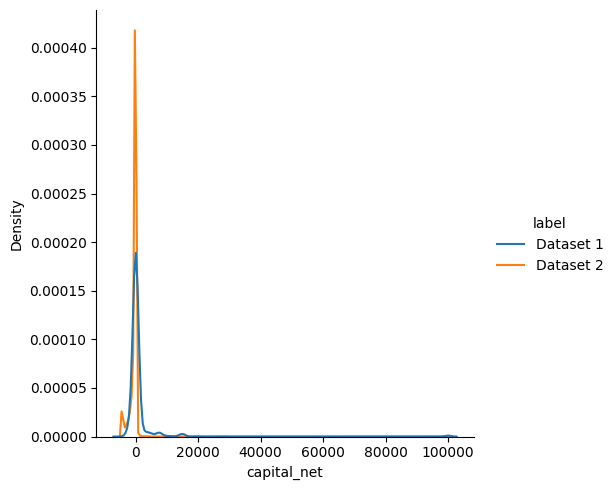

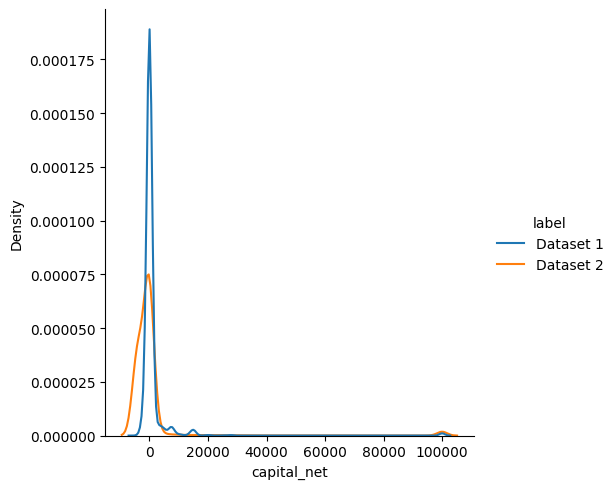

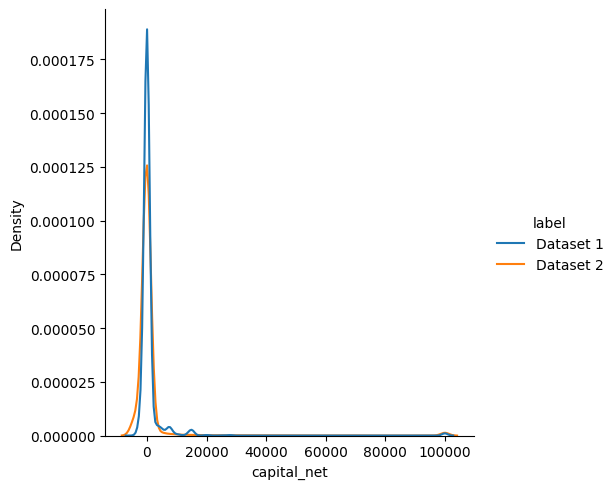

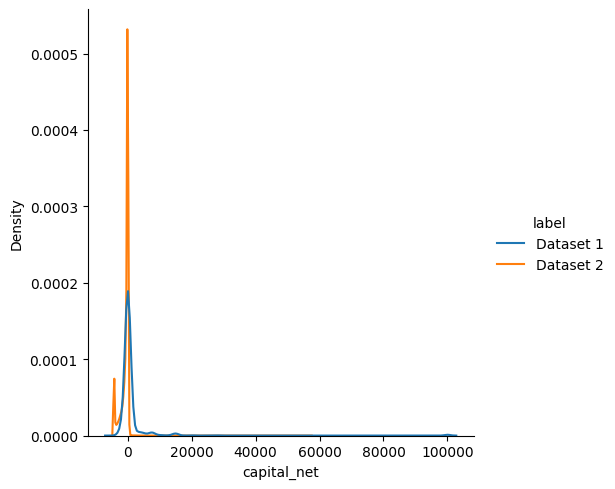

In [236]:
for epsilon in [1,3, 5, 10]:
    print("Epsilon:", epsilon)
    import math
    df_reset_copy_['capital_net_log'] = np.sign(df_reset_copy_['capital_net']) * np.log2(abs(df_reset_copy_['capital_net'])+1) 
    
    df_reset_copy_.to_csv("adult-data-census-complete.csv", index=False)
    
    df_reset_copy_2 = df_reset_copy_.copy()

    for idx, merged_lists in enumerate(current_lists):
        df_reset_copy_2[f"merged_list_{idx}"] = df_reset_copy_2[merged_lists].agg(';'.join, axis=1)
    
    
    flat_list = [
        x
        for xs in current_lists
        for x in xs
    ]
    df_reset_copy_2=df_reset_copy_2.drop(flat_list, axis=1)
    df_reset_copy_2.to_csv("adult-data-census-complete2.csv", index=False)
    
    import pandas as pd
    import math
    from snsynth import Synthesizer
    
    pums = pd.read_csv("adult-data-census-complete2.csv")

    synth = Synthesizer.create("dpctgan", epsilon=epsilon, epochs=1800, batch_size=2000)
    synth.fit(pums, preprocessor_eps=epsilon*0.3)
    synthetic_data_ = synth.sample(len(df_reset_copy_))
    df_reset_copy_2 = df_reset_copy_.copy()
    synthetic_data_['capital_net_log'] = synthetic_data_['capital_net_log'].clip(upper=max(df_reset_copy_2['capital_net_log']), lower=min(df_reset_copy_2['capital_net_log']))
    synthetic_data_['capital_net'] = round(np.sign(synthetic_data_['capital_net_log']) * (np.exp2(abs(synthetic_data_['capital_net_log']))+1)).astype(int)
    synthetic_data_['capital_net'] = synthetic_data_['capital_net'].clip(upper=max(df_reset_copy_['capital_net']), lower=min(df_reset_copy_['capital_net']))

    print("max min=", max(synthetic_data_['capital_net']), min(synthetic_data_['capital_net']))
    
    df_reset_copy_2 = df_reset_copy_2.drop('capital_net_log', axis=1)
    synthetic_data_ = synthetic_data_.drop('capital_net_log', axis=1)
    
    for idx, merged_lists in enumerate(current_lists):
        cols = synthetic_data_[f"merged_list_{idx}"].str.split(';', expand=True)
        synthetic_data_[merged_lists] = cols
        synthetic_data_ = synthetic_data_.drop(f"merged_list_{idx}", axis=1)
    df_reset_copy_2.to_csv("adult-data-census-complete2.csv", index=False)
    data = connector.read(
        folder_name='',
        file_names=['adult-data-census-complete2.csv'],
        read_csv_parameters={
            'parse_dates': False,
            'encoding':'latin-1'
        }
    )
    from sdv.metadata import Metadata
    
    metadata = Metadata.detect_from_dataframes(data)
    
    metadata.visualize()
    metadata.update_column(
        column_name='education_num',
        sdtype='numerical',
        table_name='adult-data-census-complete2'
    )
    metadata.validate()
    metadata_dict = metadata.to_dict()
    metadata_dict['columns'] = metadata_dict['tables']['adult-data-census-complete2']['columns']
    from sdmetrics.reports.single_table import QualityReport
    report1 = DiagnosticReport()
    report1.generate(df_reset_copy_, synthetic_data_, metadata_dict)

    
    
    report2 = QualityReport()
    report2.generate(df_reset_copy_2, synthetic_data_, metadata_dict)
    column_shapes = report2.get_details(property_name='Column Shapes')
    print(column_shapes)
       
  
    score_value_fidelity = round(report1.get_score(), ndigits=4) * 0.25 + round(report2.get_score(), ndigits=4) * 0.75
    score_value_fidelity = float(score_value_fidelity * 100)
    
    
    import seaborn as sns
    df_reset_copy__ = df_reset_copy_.copy()
    synthetic_data__ = synthetic_data_.copy()
    print("max min 2=", max(synthetic_data__['capital_net']), min(synthetic_data__['capital_net']))
    df_reset_copy__['label'] = 'Dataset 1'
    synthetic_data__['label'] = 'Dataset 2'
    
    combined_data = pd.concat([df_reset_copy__, synthetic_data__])
    
    sns.displot(combined_data, x="capital_net", kind="kde", hue='label')

    from sklearn.model_selection import train_test_split
    x_train_real, x_test_real, y_train_real, y_test_real = train_test_split(df_reset_copy_2.copy().loc[:, df_reset_copy_2.columns != target_column], df_reset_copy_2.copy().loc[:, df_reset_copy_2.columns == target_column], test_size=0.2, random_state=42)
    x_train_syn, x_test_syn, y_train_syn, y_test_syn = train_test_split(synthetic_data_.copy().loc[:, synthetic_data_.columns != target_column], synthetic_data_.copy().loc[:, synthetic_data_.columns == target_column], test_size=0.2, random_state=42)
    encoder = OneHotEncoder(sparse_output=False)
    one_hot_encoded_y_train = encoder.fit_transform(y_train_real)
    one_hot_df_y_train = pd.DataFrame(one_hot_encoded_y_train,  columns=encoder.get_feature_names_out(y_train_real.columns), index= y_train_real.index)
    y_train_real = pd.concat([one_hot_df_y_train], axis=1)
    
    y_test_real_copy = y_test_real.copy()
    one_hot_encoded_y_test = encoder.transform(y_test_real)
    one_hot_df_y_test = pd.DataFrame(one_hot_encoded_y_test,  columns=encoder.get_feature_names_out(y_test_real.columns), index= y_test_real.index)
    y_test_real = pd.concat([one_hot_df_y_test], axis=1)
    
    encoder = OneHotEncoder(sparse_output=False)
    one_hot_encoded_y_train_syn = encoder.fit_transform(y_train_syn)
    one_hot_df_y_train_syn = pd.DataFrame(one_hot_encoded_y_train_syn,  columns=encoder.get_feature_names_out(y_train_syn.columns), index= y_train_syn.index)
    y_train_syn = pd.concat([one_hot_df_y_train_syn], axis=1)
    
    one_hot_encoded_y_test_syn = encoder.transform(y_test_syn)
    one_hot_df_y_test_syn = pd.DataFrame(one_hot_encoded_y_test_syn,  columns=encoder.get_feature_names_out(y_test_syn.columns), index= y_test_syn.index)
    y_test_syn = pd.concat([one_hot_df_y_test_syn], axis=1)
    
    one_hot_encoded_y_test_copy = encoder.transform(y_test_real_copy)
    one_hot_df_y_test_copy = pd.DataFrame(one_hot_encoded_y_test_copy,  columns=encoder.get_feature_names_out(y_test_real_copy.columns), index= y_test_real_copy.index)
    y_test_real_copy = pd.concat([one_hot_df_y_test_copy], axis=1)
    
    x_test_real_copy = x_test_real.copy() 
    encoder = OneHotEncoder(sparse_output=False)
    one_hot_encoded_x_train = encoder.fit_transform(x_train_real[is_col_OH])
    one_hot_df_x_train = pd.DataFrame(one_hot_encoded_x_train,  columns=encoder.get_feature_names_out(is_col_OH), index= x_train_real.index)
    x_train_real = pd.concat([x_train_real.drop(is_col_OH, axis=1), one_hot_df_x_train], axis=1)
    
    one_hot_encoded_x_test = encoder.transform(x_test_real[is_col_OH])
    one_hot_df_x_test = pd.DataFrame(one_hot_encoded_x_test,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_real.index)
    x_test_real = pd.concat([x_test_real.drop(is_col_OH, axis=1), one_hot_df_x_test], axis=1)

    one_hot_encoded_x_train_syn = encoder.transform(x_train_syn[is_col_OH])
    one_hot_df_x_train_syn = pd.DataFrame(one_hot_encoded_x_train_syn,  columns=encoder.get_feature_names_out(is_col_OH), index= x_train_syn.index)
    x_train_syn = pd.concat([x_train_syn.drop(is_col_OH, axis=1), one_hot_df_x_train_syn], axis=1)
    
    one_hot_encoded_x_test_syn = encoder.transform(x_test_syn[is_col_OH])
    one_hot_df_x_test_syn = pd.DataFrame(one_hot_encoded_x_test_syn,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_syn.index)
    x_test_syn = pd.concat([x_test_syn.drop(is_col_OH, axis=1), one_hot_df_x_test_syn], axis=1)
    
    one_hot_encoded_x_test_copy = encoder.transform(x_test_real_copy[is_col_OH])
    one_hot_df_x_test_copy = pd.DataFrame(one_hot_encoded_x_test_copy,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_real_copy.index)
    x_test_real_copy = pd.concat([x_test_real_copy.drop(is_col_OH, axis=1), one_hot_df_x_test_copy], axis=1)
    
    if len(y_train_real.columns) == 2 and target_column not in y_train_real.columns:
        y_train_real = y_train_real.drop(y_train_real.columns[0], axis=1)
        y_test_real = y_test_real.drop(y_test_real.columns[0], axis=1)
        y_test_real_copy = y_test_real_copy.drop(y_test_real_copy.columns[0], axis=1)
        y_train_syn = y_train_syn.drop(y_train_syn.columns[0], axis=1)
        y_test_syn = y_test_syn.drop(y_test_syn.columns[0], axis=1)
    
    model_configs = [
        (LogisticRegression, dict(max_iter=10000, C=0.1, random_state=42), False, "synthetic"),
        (LogisticRegression, dict(max_iter=10000, C=1.0, random_state=42), False, "synthetic"),
        (LogisticRegression, dict(max_iter=500,   C=0.1, random_state=42), False, "synthetic"),
        (LogisticRegression, dict(max_iter=2500,  C=0.1, random_state=42), False, "synthetic"),
        (LogisticRegression, dict(max_iter=10000, C=10.0, random_state=42), False, "real"),
        (LogisticRegression, dict(max_iter=50,    C=0.1, random_state=42), False, "real"),
    
        (RandomForestClassifier, dict(max_depth=10, max_samples=0.9, n_estimators=200, n_jobs=-1, random_state=42), False, "synthetic"),
        (RandomForestClassifier, dict(max_depth=50, max_samples=0.8, n_estimators=50,  n_jobs=-1, random_state=42), False, "synthetic"),
        (RandomForestClassifier, dict(max_depth=10, max_samples=0.8, n_estimators=100, n_jobs=-1, random_state=42), False, "synthetic"),
        (RandomForestClassifier, dict(max_depth=10, max_samples=0.8, n_estimators=200, n_jobs=-1, random_state=42), False, "synthetic"),
        (RandomForestClassifier, dict(max_depth=100,max_samples=0.5, n_estimators=200, n_jobs=-1, random_state=42), False, "real"),
        (RandomForestClassifier, dict(max_depth=10, max_samples=0.8, n_estimators=100, n_jobs=-1, random_state=42), False, "real"),
        (RandomForestClassifier, dict(max_depth=10, max_samples=0.8, n_estimators=200, n_jobs=-1, random_state=42), False, "real"),
    
        (svm.SVC, dict(C=10.0,  max_iter=10000, decision_function_shape="ovr", random_state=42), False, "synthetic"),
        (svm.SVC, dict(C=10.0,  max_iter=5000,  decision_function_shape="ovo", random_state=42), False, "synthetic"),
        (svm.SVC, dict(C=1.0,   max_iter=10000, decision_function_shape="ovr", random_state=42), False, "synthetic"),
        (svm.SVC, dict(C=10.0,  max_iter=1500,  decision_function_shape="ovo", random_state=42), False, "synthetic"),
        (svm.SVC, dict(C=100.0, max_iter=6330,  decision_function_shape="ovr", random_state=42), False, "synthetic"),
        (svm.SVC, dict(C=10.0,  max_iter=10000, decision_function_shape="ovr", random_state=42), False, "real"),
        (svm.SVC, dict(C=1.0,   max_iter=10000, decision_function_shape="ovr", random_state=42), False, "real"),
        (svm.SVC, dict(C=10.0,  max_iter=5000,  decision_function_shape="ovr", random_state=42), False, "real"),
        (svm.SVC, dict(C=10.0,  max_iter=5375,  decision_function_shape="ovr", random_state=42), False, "real"),
        (svm.SVC, dict(C=0.1,   max_iter=500,   decision_function_shape="ovo", random_state=42), False, "real"),
    
        (KNeighborsClassifier, dict(n_neighbors=50,  leaf_size=200), True, "synthetic"),
        (KNeighborsClassifier, dict(n_neighbors=200, leaf_size=200), True, "synthetic"),
        (KNeighborsClassifier, dict(n_neighbors=5,   leaf_size=200), True, "synthetic"),
        (KNeighborsClassifier, dict(n_neighbors=50,  leaf_size=30),  True, "real"),
        (KNeighborsClassifier, dict(n_neighbors=5,   leaf_size=200), True, "real"),
        (KNeighborsClassifier, dict(n_neighbors=200, leaf_size=50),  True, "real"),
        (KNeighborsClassifier, dict(n_neighbors=50,  leaf_size=2),   True, "real"),
    
        (DecisionTreeClassifier, dict(criterion='entropy', min_samples_split=50,  min_samples_leaf=100), False, "synthetic"),
        (DecisionTreeClassifier, dict(criterion='gini',    min_samples_split=20,  min_samples_leaf=100), False, "synthetic"),
        (DecisionTreeClassifier, dict(criterion='log_loss',min_samples_split=20,  min_samples_leaf=100), False, "synthetic"),
        (DecisionTreeClassifier, dict(criterion='log_loss',min_samples_split=2,   min_samples_leaf=1),   False, "synthetic"),
        (DecisionTreeClassifier, dict(criterion='entropy', min_samples_split=50,  min_samples_leaf=100), False, "real"),
        (DecisionTreeClassifier, dict(criterion='gini',    min_samples_split=200, min_samples_leaf=1),   False, "real"),
        (DecisionTreeClassifier, dict(criterion='entropy', min_samples_split=50,  min_samples_leaf=100), False, "real"),
    ]
    
    scaler = StandardScaler()
    scaler.fit(x_train_syn[is_col_numeric])
    
    x_train_syn_scaled = x_train_syn.copy()
    x_train_syn_scaled[is_col_numeric] = scaler.transform(x_train_syn[is_col_numeric])
    x_train_real_scaled = x_train_real.copy()
    x_train_real_scaled[is_col_numeric] = scaler.transform(x_train_real[is_col_numeric])
    x_test_real_scaled = x_test_real.copy()
    x_test_real_scaled[is_col_numeric] = scaler.transform(x_test_real[is_col_numeric])
    
    target_col = y_test_real_copy.columns[0]
    rows = []
    
    for model_cls, kwargs, needs_scaling, data_type in model_configs:
        if data_type == "synthetic":
            X_train, y_train_ = (x_train_syn_scaled, y_train_syn) if needs_scaling else (x_train_syn, y_train_syn)
        else:
            X_train, y_train_ = (x_train_real_scaled, y_train_real) if needs_scaling else (x_train_real, y_train_real)
    
        X_test = x_test_real_scaled if needs_scaling else x_test_real
    
        model = model_cls(**kwargs)
        model.fit(X_train, y_train_[y_train_.columns[0]])
        y_pred = model.predict(X_test)
        y_true = y_test_real_copy[target_col]
    
        rows.append({
            "model_name": model_cls.__name__,
            "data_type": data_type,
            "hyper_parameters": str(kwargs),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred),
            "recall": recall_score(y_true, y_pred),
            "roc_auc": roc_auc_score(y_true, y_pred),
            "auprc": average_precision_score(y_true, y_pred),
        })
    
    table_element_real = pd.DataFrame(rows)
    
    import polars as pl
    
    from great_tables import GT, from_column, style, loc
    from great_tables.data import airquality
    table_element_real = table_element_real.sort_values(by=['model_name', 'auprc', 'data_type'], ascending=False, ignore_index=True)
    
    gt_table_element = GT(table_element_real)
    location_list = []
    for idx, elements in enumerate(table_element_real.columns):
        if "accuracy" in elements or "precision" in elements or "auprc" in elements or "recall" in elements or "roc_auc" in elements:
            pos_min, pos_max = (np.argmin(table_element_real[elements]), np.argmax(table_element_real[elements]))
            location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
            
    
    idx_list = []
    for models in table_element_real['model_name'].unique():
        for data_type in table_element_real['data_type'].unique():
            idx_list.append(int(table_element_real[table_element_real['model_name']==models][table_element_real['data_type']==data_type]['auprc'].index[0]))
    
    table_element_real_copy = table_element_real.copy()
    table_element_real_copy = table_element_real_copy.loc[idx_list, :]
    table_element_real_copy.index = list(range(len(idx_list)))
    values_dict2 = {}
    values_dict2["model_name"] = []
    values_dict2["difference_between_data_type"] = []
    values_dict2["percentage_reduction"] = []
    values_dict2["synthetic_data_auprc"] = []
    values_dict2["real_data_auprc"] = []
    for _model_columns in table_element_real_copy["model_name"].unique():
        dif_in_percentage=table_element_real_copy[table_element_real_copy["model_name"]==_model_columns]
        dif_in_percentage_syn = table_element_real_copy[table_element_real_copy["model_name"]==_model_columns][table_element_real_copy["data_type"]=="synthetic"]
        dif_in_percentage_real = table_element_real_copy[table_element_real_copy["model_name"]==_model_columns][table_element_real_copy["data_type"]=="real"]
    
        dif_copy = dif_in_percentage_real["auprc"].to_list()[0]-dif_in_percentage_syn["auprc"].to_list()[0]
        dif_in_percentage_copy = (dif_in_percentage_real["auprc"].to_list()[0]-dif_in_percentage_syn["auprc"].to_list()[0])/dif_in_percentage_real["auprc"].to_list()[0]
        
        values_dict2["model_name"].append(_model_columns)
        values_dict2["difference_between_data_type"].append(dif_copy)
        values_dict2["percentage_reduction"].append(round(dif_in_percentage_copy*100, ndigits=2))
        values_dict2["synthetic_data_auprc"].append(dif_in_percentage_syn["auprc"].to_list()[0])
        values_dict2["real_data_auprc"].append(dif_in_percentage_real["auprc"].to_list()[0])
    
    table_element_real = pd.DataFrame({'model_name': values_dict2['model_name'], 'synthetic_data_auprc': values_dict2['synthetic_data_auprc'], 'real_data_auprc': values_dict2['real_data_auprc'], 'difference_between_data_type':values_dict2['difference_between_data_type'], 'percentage_reduction': values_dict2['percentage_reduction']})
    
    print(table_element_real)
    
    mean_value_ratio = 0
    for idx in table_element_real.index:
        mean_value_ratio += table_element_real['synthetic_data_auprc'][idx]/table_element_real['real_data_auprc'][idx]
    score_value_utility = float(round(mean_value_ratio/len(table_element_real), ndigits=4) * 100)
    
    
    x_train_real_1, x_train_real_2 = train_test_split(
    x_train_real, test_size=0.5, random_state=42)
    
    scaler = StandardScaler()
    scaler.fit(x_train_syn[is_col_numeric])
    x_train_syn_scaled_sample = scaler.transform(x_train_syn[is_col_numeric].sample(n=2000, random_state=42))
    x_train_real_scaled_sample = scaler.transform(x_train_real[is_col_numeric].sample(n=2000, random_state=42))
    x_test_syn_scaled_sample = scaler.transform(x_test_syn[is_col_numeric].sample(n=2000, random_state=42))
    x_test_real_scaled_sample = scaler.transform(x_test_real[is_col_numeric].sample(n=2000, random_state=42))
    
    x_train_real_scaled_sample_1 = scaler.transform(x_train_real_1[is_col_numeric].sample(n=2000, random_state=42))
    x_train_real_scaled_sample_2 = scaler.transform(x_train_real_2[is_col_numeric].sample(n=2000, random_state=42))
    
    x_train_syn_copy_sampled = x_train_syn.copy().sample(n=2000, random_state=42)
    x_test_syn_copy_sampled = x_test_syn.copy().sample(n=2000, random_state=42)
    
    x_train_real_copy_sampled = x_train_real.copy().sample(n=2000, random_state=42)
    
    x_train_real_copy_sampled_1 = x_train_real_1.copy().sample(n=2000, random_state=42)
    x_train_real_copy_sampled_2 = x_train_real_2.copy().sample(n=2000, random_state=42)
    
    x_test_real_copy_sampled = x_test_real.copy().sample(n=2000, random_state=42)
    
    y_train_syn_copy_sampled = y_train_syn.copy().sample(n=2000, random_state=42)
    y_test_syn_copy_sampled = y_test_syn.copy().sample(n=2000, random_state=42)
    
    y_train_real_copy_sampled = y_train_real.copy().sample(n=2000, random_state=42)
    y_test_real_copy_sampled = y_test_real.copy().sample(n=2000, random_state=42)
    
    x_train_syn_copy_sampled[is_col_numeric] = x_train_syn_scaled_sample
    x_train_real_copy_sampled[is_col_numeric] = x_train_real_scaled_sample
    x_test_syn_copy_sampled[is_col_numeric] = x_test_syn_scaled_sample
    x_test_real_copy_sampled[is_col_numeric] = x_test_real_scaled_sample
    x_train_real_copy_sampled_1[is_col_numeric] = x_train_real_scaled_sample_1
    x_train_real_copy_sampled_2[is_col_numeric] = x_train_real_scaled_sample_2
    
    
    from sklearn.metrics import pairwise_distances
    
    pw_dist = pairwise_distances(x_train_real_copy_sampled, x_train_syn_copy_sampled, metric='euclidean')
    pw_dist2 = pairwise_distances(x_train_real_copy_sampled_1, x_train_real_copy_sampled_2, metric='euclidean')
    pw_dist_min = pw_dist.min(axis=1)
    pw_dist_min2 = pw_dist2.min(axis=1)
    list_pw_dist = pw_dist_min.copy()
    list_pw_dist2 = pw_dist_min2.copy()
    list_pw_dist.sort()
    list_pw_dist2.sort()
    
    mean_1 = list_pw_dist.mean()
    mean_2 = list_pw_dist2.mean()
    score_dcr = min(mean_1/mean_2, 1.0) * 100.0
    x_real = pd.concat([x_train_real, x_test_real], ignore_index=False)
    y_real = pd.concat([y_train_real, y_test_real], ignore_index=False)
    x_syn_real = pd.concat([x_train_syn, x_test_real], ignore_index=False)
    y_syn_real = pd.concat([y_train_syn, y_test_real], ignore_index=False)
        
    best_model = LogisticRegression(max_iter=10000, C=0.1, random_state=42)
    best_model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
    predict_prob = best_model.predict_proba(x_real)
    
    best_model = LogisticRegression(max_iter=10000, C=0.1, random_state=42)
    best_model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
    predict_prob = best_model.predict_proba(x_real)
    
    list_of_mitm_values = []
    list_of_mitm_values_train = []
    list_of_mitm_values_test = []
    for idx in range(len(x_real)):
        current_sample = x_real.loc[x_real.index[idx], :]
        current_label = y_real.loc[y_real.index[idx], :]
        is_in_train, loss = check_if_values_okay(predict_prob[idx], current_label, y_real.columns[0])
        list_of_mitm_values.append((loss, int(x_real.index[idx])))
    
        if x_real.index[idx] in list(x_train_real.index):
            list_of_mitm_values_train.append((loss, int(x_real.index[idx])))
        elif x_real.index[idx] in list(x_test_real.index):
            list_of_mitm_values_test.append((loss, int(x_real.index[idx])))

    avg_train_1 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_train)))
    avg_test_1 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_test)))
    score_mitm_1 = min(avg_train_1/avg_test_1, 1.0) * 100
    
    x_syn_real = pd.concat([x_train_syn, x_test_real], ignore_index=False)
    y_syn_real = pd.concat([y_train_syn, y_test_real], ignore_index=False)
    
    best_model = LogisticRegression(max_iter=10000, C=0.1, random_state=42)
    best_model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
    predict_prob = best_model.predict_proba(x_syn_real)
    
    list_of_mitm_values_2 = []
    list_of_mitm_values_train_2 = []
    list_of_mitm_values_test_2 = []
    for idx in range(len(x_syn_real)):
        current_sample = x_syn_real.loc[x_syn_real.index[idx], :]
        current_label = y_syn_real.loc[y_syn_real.index[idx], :]
        is_in_train, loss = check_if_values_okay(predict_prob[idx], current_label, y_syn_real.columns[0])
        list_of_mitm_values_2.append((loss, int(x_syn_real.index[idx])))
    
        if x_syn_real.index[idx] in list(x_train_syn.index):
            list_of_mitm_values_train_2.append((loss, int(x_syn_real.index[idx])))
        elif y_syn_real.index[idx] in list(x_test_real.index):
            list_of_mitm_values_test_2.append((loss, int(x_syn_real.index[idx])))
    
    avg_train_2 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_train_2)))
    avg_test_2 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_test_2)))
    score_mitm_2 = min(avg_train_2/avg_test_2, 1.0) * 100
    
    score_value_privacy = score_dcr * 0.5 + score_mitm_1 * 0.25 + score_mitm_2 * 0.25
    okay=0
    score_value_categorical_diversity = 0
    from functools import reduce
    
    for columns in is_col_categorical:
        list_of_categories = (list(df_reset_copy_2[columns].unique()))
        list_of_categories_that_appear_on_synthetic = list(filter(lambda x: x in list(synthetic_data_[columns]), list_of_categories))
        if len(list_of_categories) != len(list_of_categories_that_appear_on_synthetic):
            okay=1
    
    list_of_values_different = []
    for columns in is_col_categorical:
        counts_per_category_real = (dict(df_reset_copy_2[columns].value_counts()))
        counts_per_category_synthetic = (dict(synthetic_data_[columns].value_counts()))
        
        counts_per_category_real_per = dict(map(lambda k: (k[0], float(round((k[1]/len(df_reset_copy_2)), ndigits=6))), counts_per_category_real.items()))
        counts_per_category_syn_per = dict(map(lambda k: (k[0], float(round((k[1]/len(synthetic_data_)), ndigits=6))), counts_per_category_synthetic.items()))
        
        counts_per_category_real_per_not_present = dict(filter(lambda k: k[0] not in counts_per_category_synthetic.keys(), counts_per_category_real_per.items()))
        counts_per_category_syn_per_not_present = dict(filter(lambda k: k[0] not in counts_per_category_real.keys(), counts_per_category_syn_per.items()))

        counts_per_category_real_per = dict(filter(lambda k: k[0] in counts_per_category_synthetic.keys(), counts_per_category_real_per.items()))
        counts_per_category_syn_per = dict(filter(lambda k: k[0] in counts_per_category_real.keys(), counts_per_category_syn_per.items()))
    
        counts_per_category_both_per = list(map(lambda k, v: (k[0], k[1], v[1]), counts_per_category_real_per.items(), counts_per_category_syn_per.items()))
        counts_per_category_both_per = list(filter(lambda k: k[1]!=k[2], counts_per_category_both_per))
        if counts_per_category_both_per != []:
            counts_per_category_real_per_not_present = list(map(lambda k: (k[0], k[1], 0.0), counts_per_category_real_per_not_present.items()))
            counts_per_category_syn_per_not_present = list(map(lambda k: (k[0], 0.0, k[1]), counts_per_category_syn_per_not_present.items()))
    
            list_of_values_different.extend(counts_per_category_both_per)
            list_of_values_different.extend(counts_per_category_real_per_not_present)
            list_of_values_different.extend(counts_per_category_syn_per_not_present)
    
    
    if list_of_values_different == []:
        score_value_categorical_diversity = 0.0
        
    else:
        biggest_categorical_diversity = list(map(lambda k: (k[0], abs(k[1]-k[2])), list_of_values_different))
        biggest_categorical_diversity.sort(key=lambda item: item[1], reverse=True)
        score_value_categorical_diversity = reduce(lambda k, y : abs(y[1]-y[2])+k, list_of_values_different, 0.0)
        
        score_value_categorical_diversity = (1-(score_value_categorical_diversity/len(is_col_categorical))) * 100.0
    binary_numerical_columns = list(filter(lambda x: len(df_reset_copy_2[x].unique())==2, list(df_reset_copy_2.columns)))
    
    difference_value = 0
    for b_column in binary_numerical_columns:
        value_1_real = df_reset_copy_2[df_reset_copy_2[b_column]==df_reset_copy_2[b_column].unique()[0]]
        value_2_real = df_reset_copy_2[df_reset_copy_2[b_column]==df_reset_copy_2[b_column].unique()[1]]
        
        value_1_syn = synthetic_data_[synthetic_data_[b_column]==df_reset_copy_2[b_column].unique()[0]]
        value_2_syn = synthetic_data_[synthetic_data_[b_column]==df_reset_copy_2[b_column].unique()[1]]
        
        per_value_1_real = round(len(value_1_real)/len(df_reset_copy_2), ndigits=6)
        per_value_2_real = round(len(value_2_real)/len(df_reset_copy_2), ndigits=6)
    
        per_value_1_syn = round(len(value_1_syn)/len(df_reset_copy_2), ndigits=6)
        per_value_2_syn = round(len(value_2_syn)/len(df_reset_copy_2), ndigits=6)
        difference_value += abs(per_value_1_real - per_value_1_syn)
    difference_value/=len(binary_numerical_columns)
    
    difference_value = round(difference_value, ndigits=6)
    score_value_binary_columns_diversity = (1-difference_value)*100
    score_value_binary_columns_diversity = round(score_value_binary_columns_diversity, ndigits=6)
    is_col_numeric_without_binary = list(set(is_col_numeric.copy())-(set(binary_numerical_columns)))
    
    diffferences_in_values = 0.0
    
    for col in is_col_numeric_without_binary:
        diff = 0
        for percentiles in [0.99, 0.97, 0.95, 0.93, 0.92, 0.9, 0.875, 0.8, 0.75, 0.65]:
            x = np.percentile(df_reset_copy_2[col], (1.0-percentiles)*100.0)
            y = np.percentile(df_reset_copy_2[col], percentiles*100.0)
    
            per_syn = round(len(synthetic_data_[synthetic_data_[col]<=y][synthetic_data_[col]>=x])/len(synthetic_data_), ndigits=6)
            per_real = round(len(df_reset_copy_2[df_reset_copy_2[col]<=y][df_reset_copy_2[col]>=x])/len(df_reset_copy_2), ndigits=6)
            diff += abs(per_real - per_syn)
        diff/=len([0.99, 0.97, 0.95, 0.93, 0.92, 0.9, 0.875, 0.8, 0.75, 0.65])
        diffferences_in_values+=diff
    diffferences_in_values/=len(is_col_numeric_without_binary)
    score_value_numerical_diversity=(1.0-diffferences_in_values)*100
    
    score_value_diversity = (len(is_col_numeric_without_binary) * score_value_numerical_diversity + len(binary_numerical_columns) * score_value_binary_columns_diversity + len(is_col_categorical) * score_value_binary_columns_diversity)/(len(is_col_categorical)+len(binary_numerical_columns)+len(is_col_numeric_without_binary))
    
    DQS = score_value_fidelity*0.1 + score_value_utility * 0.35 + score_value_privacy * 0.35 + score_value_diversity * 0.2
    score_value_fidelity_list.append(round(score_value_fidelity, ndigits=2))
    score_value_utility_list.append(round(score_value_utility, ndigits=2))
    score_value_privacy_list.append(round(score_value_privacy, ndigits=2))
    score_value_diversity_list.append(round(score_value_diversity, ndigits=2))
    DQS = round(DQS, ndigits=2)
    print(DQS)
    DQS_list.append(DQS)

It seems for smaller epsilon values that the epsilon = 5, captures the distribution of the real dataset the best and this can be seen from the value of the DQS.

When it comes to score_value_diveristy, among smaller epsilons, epsilon = 10 got the best value.

As it can be seen from the DQS, the best epsilon overall is 3000000, which is almost infinite, so there is no DP, with a score of 88.62, and this seemed to have the best values for the other metrics, except for score_value_privacy, which epsilon = 5 got slightly higher value, while paradoxically for the other epsilon values, despite being smaller than the one with no dp, it got a worse score in this department.


WARNING: THIS CAN CHANGE DEPENDING ON THE RUN, BUT IN ALL RUNS the one with no dp, scores the highest, and always there are epsilon who score higher in privacy (while not being the same). 

In [237]:
rows = []
list_epsilon = [3000000, 1,3,5,10]
for idx in range(len(DQS_list)):
    
    rows.append({
        "epsilon": list_epsilon[idx],
        "score_value_fidelity": score_value_fidelity_list[idx],
        "score_value_utility": score_value_utility_list[idx],
        "score_value_privacy": score_value_privacy_list[idx],
        "score_value_diversity": score_value_diversity_list[idx],
        "DQS": DQS_list[idx]
    })

In [238]:
table_element_real = pd.DataFrame(rows)
print(table_element_real)

   epsilon  score_value_fidelity  score_value_utility  score_value_privacy  \
0  3000000                 81.12                82.57                96.61   
1        1                 74.01                47.50                82.03   
2        3                 74.83                48.04                82.76   
3        5                 80.34                70.60                99.63   
4       10                 74.02                63.94                85.98   

   score_value_diversity    DQS  
0                  89.00  88.62  
1                  77.00  68.14  
2                  83.00  69.86  
3                  79.73  83.56  
4                  87.53  77.38  
